<!--<badge>--><a href="https://colab.research.google.com/github/JoeChen322/Fintech/blob/main/EDA_Merged.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a><!--</badge>-->


# Exploratory Data Analysis (EDA)

This notebook contains the exploratory analysis for the Financial Needs estimation project. It covers data quality checks, distribution diagnostics, correlation analysis, and dimensionality reduction — all of which informed our later modelling decisions.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import gdown
from scipy import stats
from scipy.stats import (
    chi2_contingency,
    mannwhitneyu,
    spearmanr,
    pearsonr,
    ks_2samp,
    shapiro,
    kruskal,
    pointbiserialr,
    normaltest,
)
from sklearn.preprocessing import StandardScaler, MinMaxScaler, PowerTransformer
from sklearn.decomposition import PCA

from sklearn.ensemble import IsolationForest
from sklearn.manifold import TSNE
from dataclasses import dataclass
from typing import List, Dict, Tuple
from scipy.stats import chi2_contingency, skew

# Reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Plot style
sns.set_theme(style="whitegrid", palette="viridis", font_scale=1.1)
plt.rcParams["figure.dpi"] = 120
plt.rcParams["savefig.dpi"] = 150

In [2]:
# Define target and feature columns
TARGET_COLS = ["IncomeInvestment", "AccumulationInvestment"]

# Categorical columns
CATEGORICAL_COLS = ["Gender"]

# Numeric columns (excluding ID and targets)
NUMERIC_COLS = [
    "Age",
    "FamilyMembers",
    "FinancialEducation",
    "RiskPropensity",
    "Income",
    "Wealth",
]

# Value mappings for categorical variables
VALUE_MAPS = {
    "Gender": {0: "Male", 1: "Female"},
    "IncomeInvestment": {0: "No Need", 1: "Has Need"},
    "AccumulationInvestment": {0: "No Need", 1: "Has Need"},
}

print(f"Target columns: {TARGET_COLS}")
print(f"Categorical columns: {CATEGORICAL_COLS}")
print(f"Numeric columns: {NUMERIC_COLS}")

Target columns: ['IncomeInvestment', 'AccumulationInvestment']
Categorical columns: ['Gender']
Numeric columns: ['Age', 'FamilyMembers', 'FinancialEducation', 'RiskPropensity', 'Income', 'Wealth']


In [3]:
# DATA LOADING FROM GOOGLE DRIVE
url = "https://drive.google.com/uc?id=1TiR645keulkG4pONLpVn-bO4elNBtNpX"
file_path = "Dataset2_Needs.xls"
gdown.download(url, file_path, quiet=False)

needs_df = pd.read_excel(file_path, sheet_name="Needs")
products_df = pd.read_excel(file_path, sheet_name="Products")
metadata_df = pd.read_excel(file_path, sheet_name="Metadata")

# Fix column names
needs_df.columns = needs_df.columns.str.strip()
products_df.columns = products_df.columns.str.strip()
metadata_df.columns = metadata_df.columns.str.strip()

print(f"Clients dataset : {needs_df.shape[0]:,} rows × {needs_df.shape[1]} columns")
print(
    f"Products catalog : {products_df.shape[0]} products × {products_df.shape[1]} attributes"
)
print(f"\nColumns: {needs_df.columns.tolist()}")
needs_df.head()

Downloading...
From: https://drive.google.com/uc?id=1TiR645keulkG4pONLpVn-bO4elNBtNpX
To: /Users/pengrao/Workspace/Fintech/Dataset2_Needs.xls
100%|██████████| 428k/428k [00:00<00:00, 7.64MB/s]


Clients dataset : 5,000 rows × 10 columns
Products catalog : 11 products × 3 attributes

Columns: ['ID', 'Age', 'Gender', 'FamilyMembers', 'FinancialEducation', 'RiskPropensity', 'Income', 'Wealth', 'IncomeInvestment', 'AccumulationInvestment']


,ID,Age,Gender,FamilyMembers,FinancialEducation,RiskPropensity,Income,Wealth,IncomeInvestment,AccumulationInvestment
0,1,60,0,2,0.228685,0.233355,68.181525,53.260067,0,1
1,2,78,0,2,0.358916,0.170911,21.807595,135.550048,1,0
2,3,33,1,2,0.317515,0.249703,23.252747,66.303678,0,1
3,4,69,1,4,0.767685,0.654597,166.189034,404.997689,1,1
4,5,58,0,3,0.429719,0.349039,21.186723,58.911930,0,0


In [ ]:
# ═══════════════════════════════════════════════════════════════
# DATA DICTIONARY & PRODUCT CATALOG
# ═══════════════════════════════════════════════════════════════
meta_dict = dict(
    zip(
        metadata_df["Metadata"].dropna().astype(str),
        metadata_df["Unnamed: 1"].dropna().astype(str),
    )
)
print("DATA DICTIONARY:")
for var, desc in meta_dict.items():
    print(f"  {str(var):30s} → {desc}")

product_names = {
    1: "Balanced Mutual Fund",
    2: "Income Conservative Unit-Linked",
    3: "Fixed Income Mutual Fund",
    4: "Balanced High Dividend MF",
    5: "Balanced Mutual Fund II",
    6: "Defensive Flex Unit-Linked",
    7: "Aggressive Flex Unit-Linked",
    8: "Balanced Flex Unit-Linked",
    9: "Cautious Alloc Segregated",
    10: "Fixed Income Segregated",
    11: "Total Return Aggr Segregated",
}

DATA DICTIONARY:
  Clients                        → Numerical ID
  ID                             → Age, in years
  Age                            → Gender (Female = 1, Male = 0)
  Gender                         → Number of components
  FamilyMembers                  → Normalized level of Financial Education (estimate)
  FinancialEducation             → Normalized Risk propensity from MIFID profile
  RiskPropensity                 → Income (thousands of euros); estimate
  Income                         → Wealth (thousands of euros); sum of investments and cash accounts
  Wealth                         → Boolean variable for Income investment; 1 = High propensity
  IncomeInvestment               → Boolean variable for Accumulation/growth investment; 1 = High propensity
  AccumulationInvestment         → Numerical ID
  Products                       → 1 = Accumulation product, 0 = Income product 
  IDProduct                      → Income Conservative Unit-Linked (Life Insurance)
  Type  

---

## 1. Descriptive Statistics & Data Quality

Before any visual or statistical analysis, we check the basics: dataset dimensions, missing values, duplicates, and summary statistics including skewness and kurtosis. This flags potential issues (e.g. heavy tails in monetary variables) early on.


In [5]:
# ═══════════════════════════════════════════════════════════════
# COMPREHENSIVE DATA QUALITY REPORT
# ═══════════════════════════════════════════════════════════════
df = needs_df.drop("ID", axis=1).copy()

print("=" * 70)
print("DATA QUALITY REPORT")
print("=" * 70)
print(f"  Total observations      : {len(df):,}")
print(f"  Missing values (total)  : {df.isnull().sum().sum()}")
print(f"  Duplicate rows          : {df.duplicated().sum()}")
print(f"  Memory usage            : {df.memory_usage(deep=True).sum() / 1024:.1f} KB")

print("\n" + "=" * 70)
print("DESCRIPTIVE STATISTICS (EXTENDED)")
print("=" * 70)
desc = df.describe().T
desc["skewness"] = df.skew()
desc["kurtosis"] = df.kurtosis()
desc["IQR"] = desc["75%"] - desc["25%"]
desc["CV"] = desc["std"] / desc["mean"]  # Coefficient of variation
print(desc.round(4).to_string())

# Data types
print("\nData Types:")
print(df.dtypes.to_string())


DATA QUALITY REPORT
  Total observations      : 5,000
  Missing values (total)  : 0
  Duplicate rows          : 0
  Memory usage            : 351.7 KB

DESCRIPTIVE STATISTICS (EXTENDED)
                         count     mean       std      min      25%      50%       75%        max  skewness  kurtosis      IQR      CV
Age                     5000.0  55.2534   11.9717  18.0000  47.0000  55.0000   63.0000    97.0000    0.0586   -0.0251  16.0000  0.2167
Gender                  5000.0   0.4920    0.5000   0.0000   0.0000   0.0000    1.0000     1.0000    0.0320   -1.9998   1.0000  1.0162
FamilyMembers           5000.0   2.5106    0.7618   1.0000   2.0000   3.0000    3.0000     5.0000    0.0647   -0.2084   1.0000  0.3035
FinancialEducation      5000.0   0.4191    0.1514   0.0361   0.3081   0.4167    0.5234     0.9029    0.1485   -0.4221   0.2153  0.3612
RiskPropensity          5000.0   0.3627    0.1511   0.0248   0.2464   0.3545    0.4671     0.8827    0.3261   -0.3494   0.2207  0.4167
Inco

## 2. Target Variable Analysis — Class Balance

We examine the prevalence of each target (`IncomeInvestment`, `AccumulationInvestment`) and test whether the two targets are independent using a chi-squared test. Knowing the class balance up front is important because it determines whether raw accuracy is a reliable metric or whether we need to focus on precision, recall, and threshold tuning.


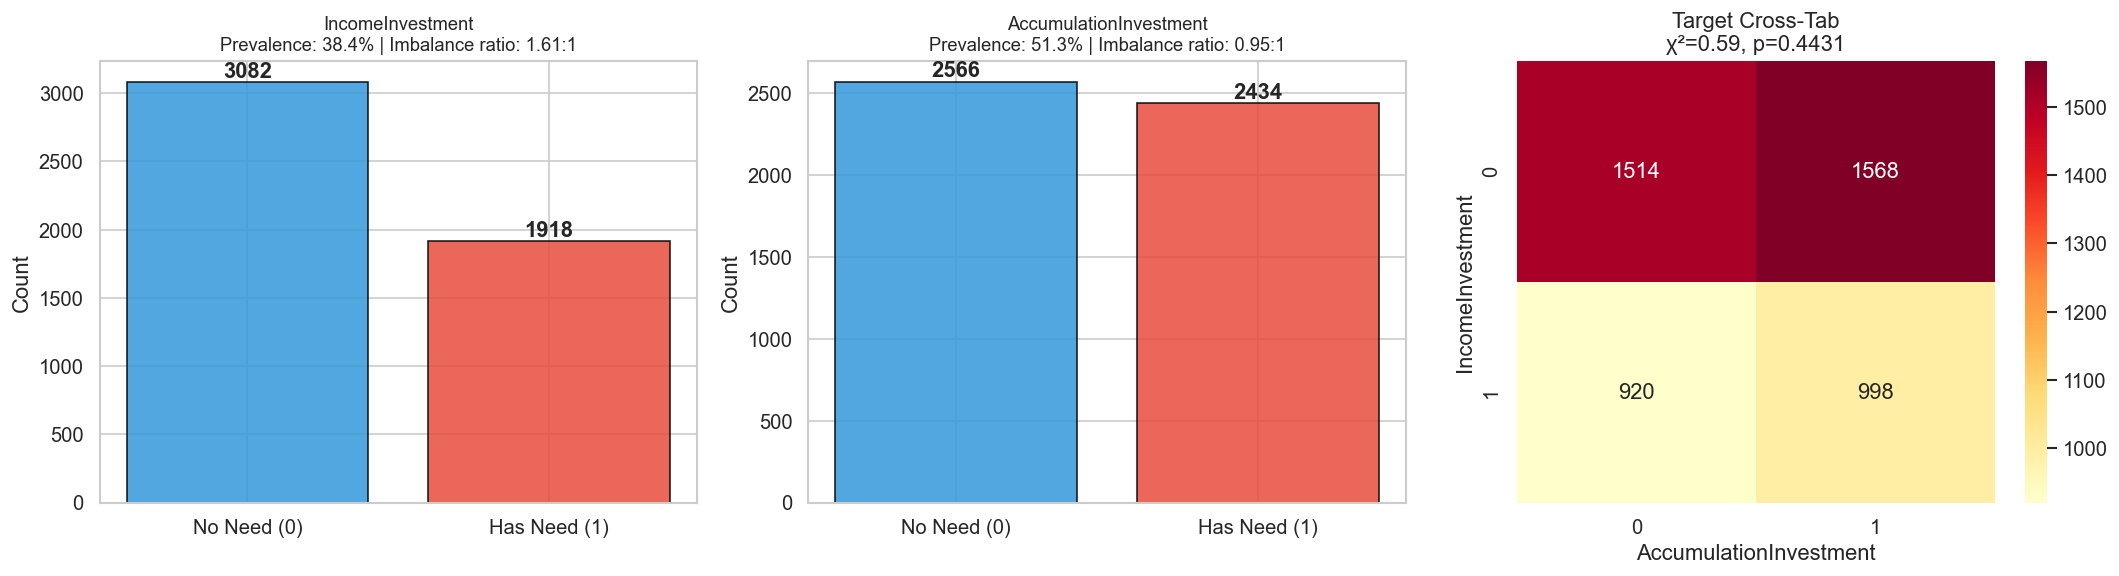

Chi-squared independence test: χ²=0.59, p=4.4306e-01
→ Targets are independent (α=0.05)
→ Separate binary classifiers (One-vs-All) are appropriate.


In [6]:
# ═══════════════════════════════════════════════════════════════
# TARGET CLASS BALANCE + CHI-SQUARED INDEPENDENCE TEST
# ═══════════════════════════════════════════════════════════════
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, target in zip(axes[:2], ["IncomeInvestment", "AccumulationInvestment"]):
    counts = df[target].value_counts()
    ratio = counts[1] / len(df)
    colors = ["#3498db", "#e74c3c"]
    bars = ax.bar(
        ["No Need (0)", "Has Need (1)"],
        counts.values,
        color=colors,
        edgecolor="black",
        alpha=0.85,
    )
    ax.set_title(
        f"{target}\nPrevalence: {ratio:.1%} | Imbalance ratio: {counts[0] / counts[1]:.2f}:1",
        fontsize=11,
    )
    ax.set_ylabel("Count")
    for bar, v in zip(bars, counts.values):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            v + 30,
            str(v),
            ha="center",
            fontweight="bold",
        )

# Cross-tabulation heatmap
ct = pd.crosstab(df["IncomeInvestment"], df["AccumulationInvestment"])
chi2, p, dof, expected = chi2_contingency(ct)
sns.heatmap(ct, annot=True, fmt="d", cmap="YlOrRd", ax=axes[2])
axes[2].set_title(f"Target Cross-Tab\nχ²={chi2:.2f}, p={p:.4f}")
axes[2].set_xlabel("AccumulationInvestment")
axes[2].set_ylabel("IncomeInvestment")

plt.tight_layout()
plt.show()

print(f"Chi-squared independence test: χ²={chi2:.2f}, p={p:.4e}")
print(f"→ Targets are {'associated' if p < 0.05 else 'independent'} (α=0.05)")
print(f"→ Separate binary classifiers (One-vs-All) are appropriate.")


To assess whether the two target variables, IncomeInvestment and AccumulationInvestment, are independent, we perform a chi-squared (χ²) test of independence. This test compares the observed frequencies of each combination of the two variables with the frequencies that would be expected if they were statistically independent. The χ² statistic measures the discrepancy between these observed and expected values, and a corresponding p-value is computed to determine whether this difference is significant. If the p-value is greater than a chosen significance level (here 0.05), we do not reject the hypothesis of independence. In our case, the test indicates a high p-value, suggesting that the two variables are indeed independent and do not exhibit a statistically significant association.


**Figure explanation:**

**Bar chart — IncomeInvestment (left):** Shows how many clients have an income-type investment need (class 1) versus those who do not (class 0). The prevalence percentage and the imbalance ratio printed in the title tell us how skewed the split is. If, for example, only ~30 % of clients have the need, a naive classifier that always predicts "no need" would already reach 70 % accuracy — so accuracy alone is not a trustworthy metric for this target.

**Bar chart — AccumulationInvestment (centre):** Same logic applied to the accumulation-type need. Comparing the two charts side by side lets us see whether one target is harder (more imbalanced) than the other, which may require different threshold-tuning strategies later.

**Heatmap — Target cross-tabulation (right):** Each cell counts how many clients fall into a specific combination of the two targets (e.g. need both, need neither, need only one). The chi-squared statistic and p-value printed in the title test whether the two targets are statistically independent. A low p-value means they co-occur more (or less) often than chance would predict, but as long as the association is not extremely strong, modelling them as two separate binary classifiers remains a reasonable approach.


## 3. Feature Distributions — Histograms, Box Plots & Q-Q Plots

For each continuous feature we plot three complementary views: a histogram with KDE overlay (to see shape and skewness), a box plot (to spot outliers and spread), and a Q-Q plot (to check deviation from normality). We also run Shapiro-Wilk and D'Agostino tests to confirm visual impressions quantitatively.


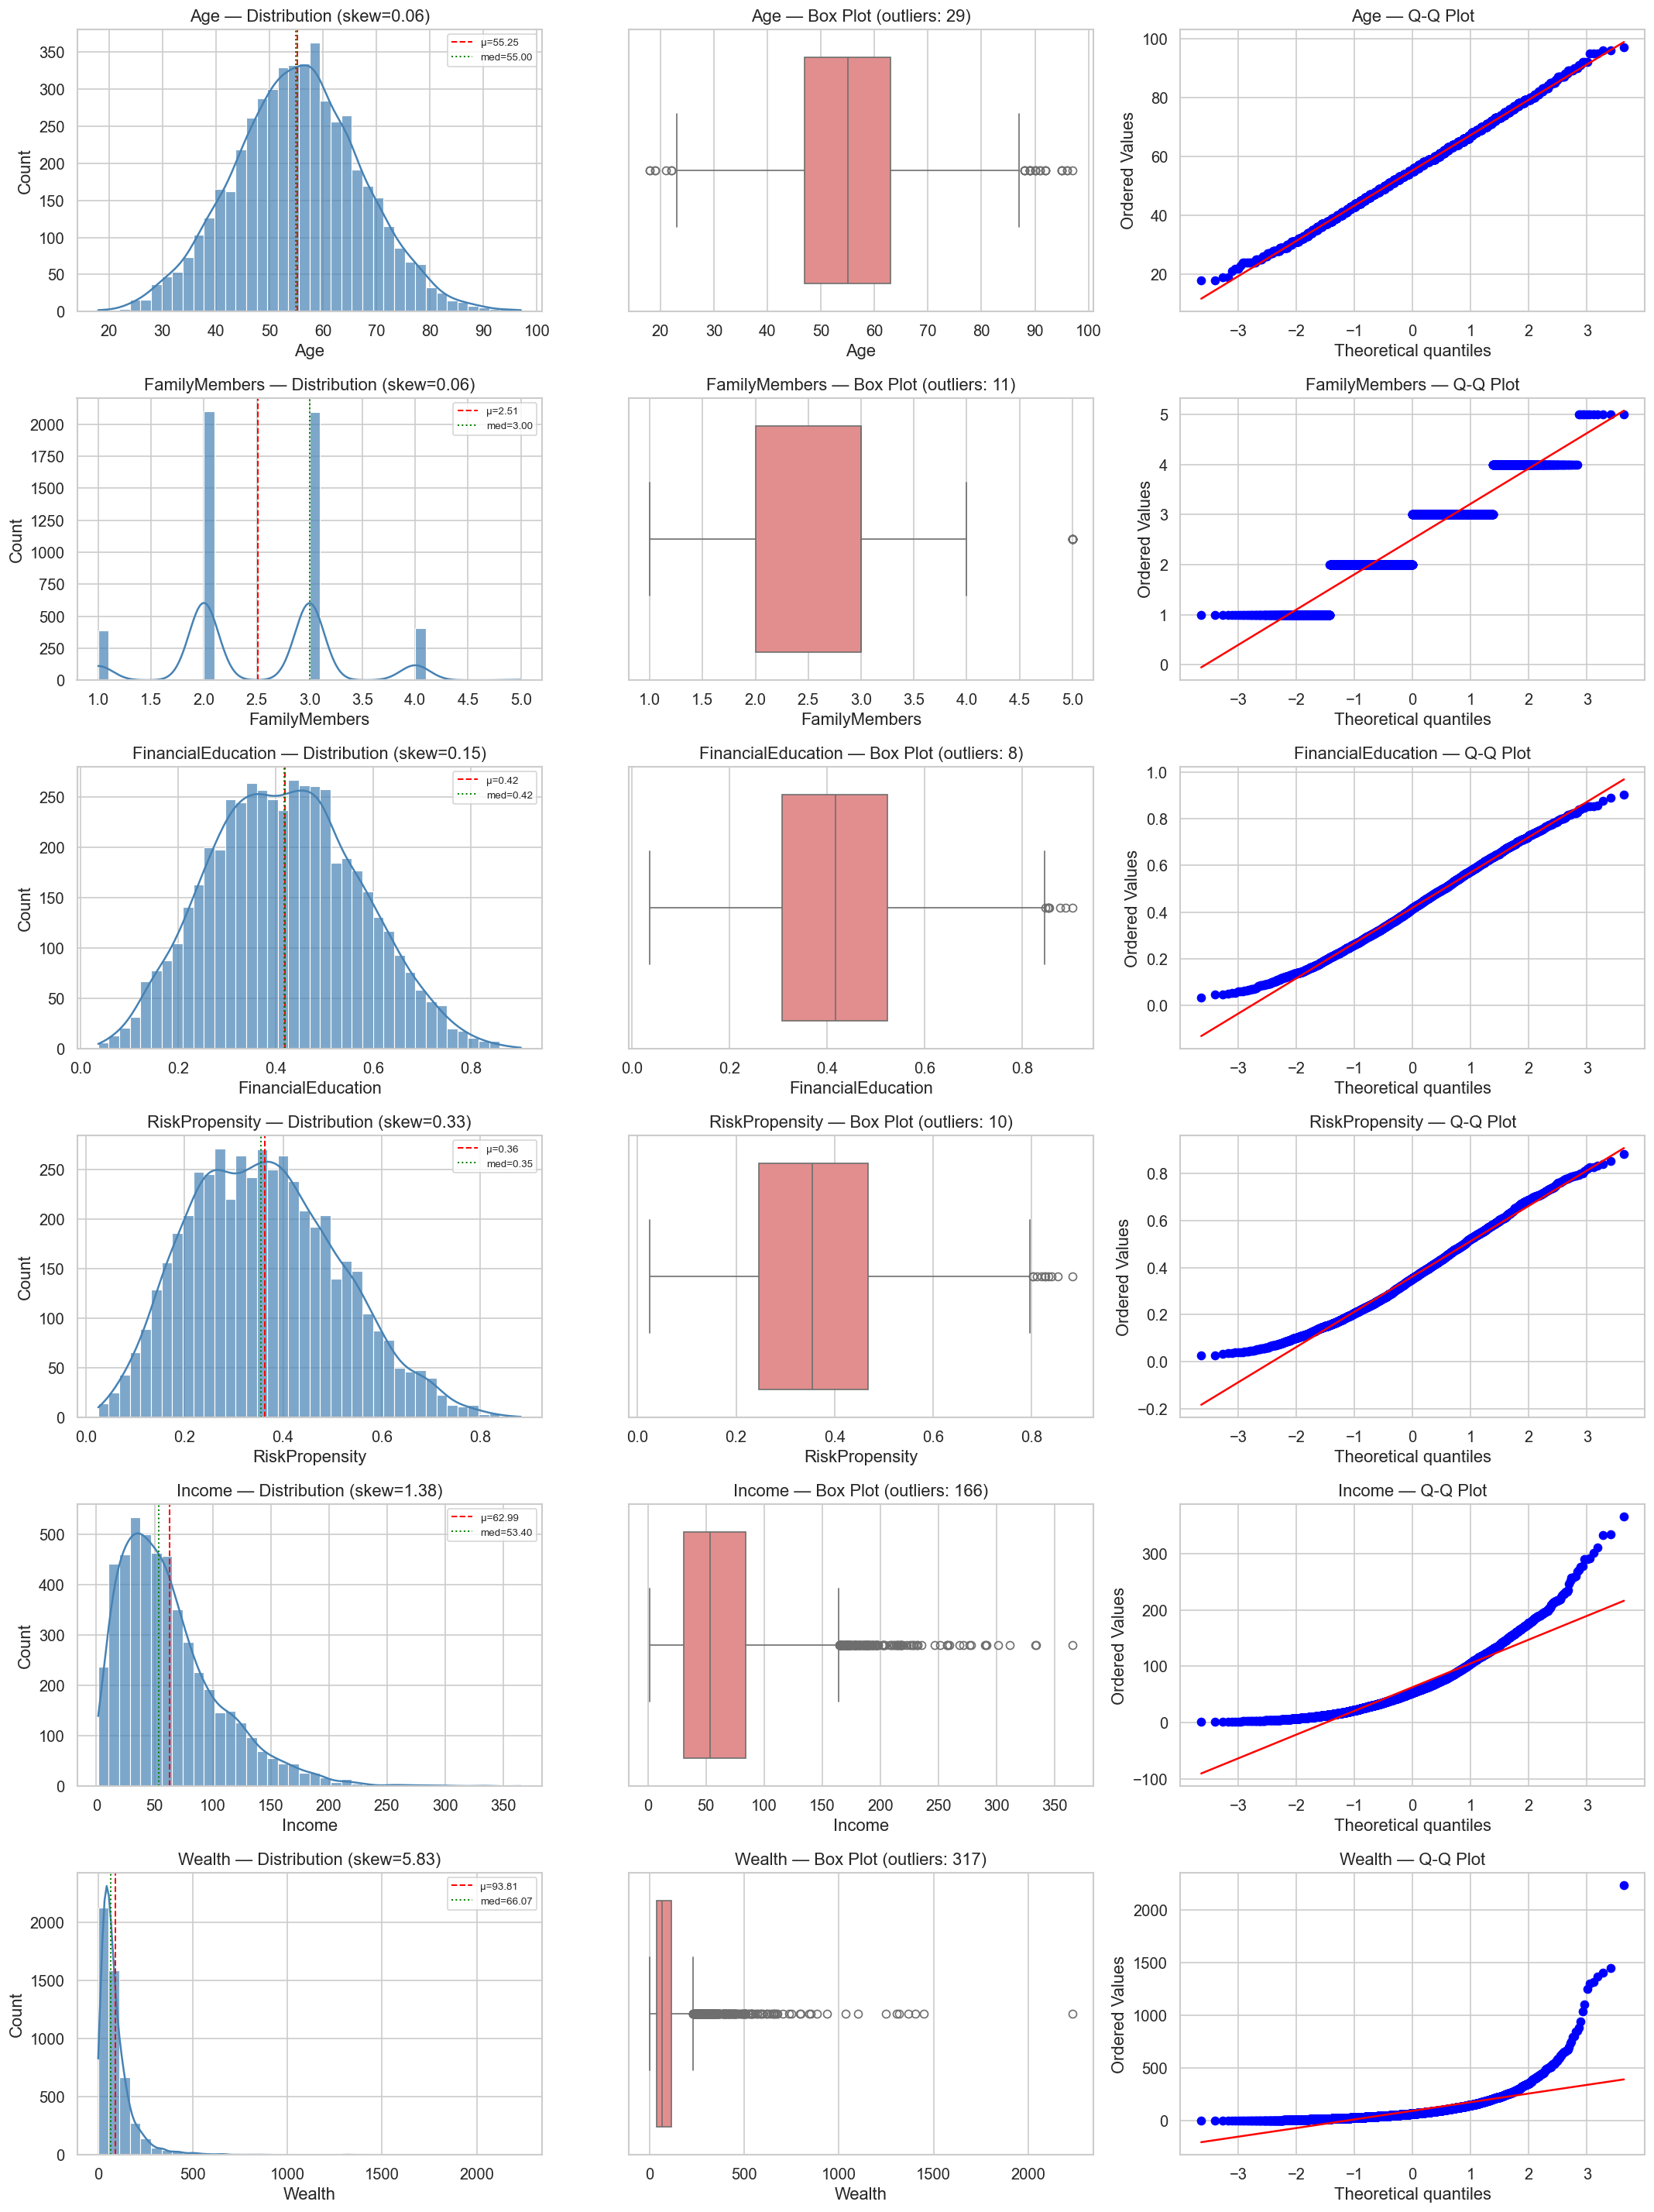


Normality Tests (Shapiro-Wilk, subsample n=500):
------------------------------------------------------------
  Age                      : Shapiro W=0.9945 (p=7.05e-02) | D'Agostino K²=1.22 (p=5.44e-01) → Normal
  FamilyMembers            : Shapiro W=0.8526 (p=3.20e-21) | D'Agostino K²=4.49 (p=1.06e-01) → Non-normal
  FinancialEducation       : Shapiro W=0.9924 (p=1.22e-02) | D'Agostino K²=12.20 (p=2.24e-03) → Non-normal
  RiskPropensity           : Shapiro W=0.9869 (p=1.79e-04) | D'Agostino K²=12.82 (p=1.64e-03) → Non-normal
  Income                   : Shapiro W=0.8634 (p=1.77e-20) | D'Agostino K²=187.67 (p=1.77e-41) → Non-normal
  Wealth                   : Shapiro W=0.6634 (p=2.99e-30) | D'Agostino K²=414.16 (p=1.17e-90) → Non-normal


In [7]:
# ═══════════════════════════════════════════════════════════════
# DISTRIBUTION ANALYSIS: Histograms + Box Plots + Q-Q Plots
# ═══════════════════════════════════════════════════════════════
continuous_features = [
    "Age",
    "FamilyMembers",
    "FinancialEducation",
    "RiskPropensity",
    "Income",
    "Wealth",
]

fig, axes = plt.subplots(
    len(continuous_features), 3, figsize=(18, 4 * len(continuous_features))
)

for i, feat in enumerate(continuous_features):
    # Histogram + KDE
    ax = axes[i, 0]
    sns.histplot(df[feat], kde=True, ax=ax, color="steelblue", bins=40, alpha=0.7)
    ax.axvline(
        df[feat].mean(), color="red", ls="--", lw=1.2, label=f"μ={df[feat].mean():.2f}"
    )
    ax.axvline(
        df[feat].median(),
        color="green",
        ls=":",
        lw=1.2,
        label=f"med={df[feat].median():.2f}",
    )
    ax.legend(fontsize=8)
    ax.set_title(f"{feat} — Distribution (skew={df[feat].skew():.2f})")

    # Box Plot
    ax2 = axes[i, 1]
    sns.boxplot(x=df[feat], ax=ax2, color="lightcoral")
    Q1, Q3 = df[feat].quantile(0.25), df[feat].quantile(0.75)
    IQR = Q3 - Q1
    outliers = ((df[feat] < Q1 - 1.5 * IQR) | (df[feat] > Q3 + 1.5 * IQR)).sum()
    ax2.set_title(f"{feat} — Box Plot (outliers: {outliers})")

    # Q-Q Plot
    ax3 = axes[i, 2]
    stats.probplot(df[feat], dist="norm", plot=ax3)
    ax3.set_title(f"{feat} — Q-Q Plot")

plt.tight_layout()
plt.show()

# Normality tests
print("\nNormality Tests (Shapiro-Wilk, subsample n=500):")
print("-" * 60)
for feat in continuous_features:
    sample = df[feat].sample(500, random_state=42)
    w_stat, w_p = shapiro(sample)
    k2, k_p = normaltest(sample)
    print(
        f"  {feat:25s}: Shapiro W={w_stat:.4f} (p={w_p:.2e}) | "
        f"D'Agostino K²={k2:.2f} (p={k_p:.2e}) → "
        f"{'Normal' if w_p > 0.05 and k_p > 0.05 else 'Non-normal'}"
    )


**Figure explanation — one row per feature:**

**Histogram + KDE (left column):** The blue histogram shows how values are spread across ranges, and the KDE curve smooths it into a continuous shape. The red dashed line marks the mean, the green dotted line marks the median. When these two lines sit close together the distribution is roughly symmetric; when the mean is pulled to the right of the median, the variable is right-skewed. The skewness value printed in the title quantifies this. For `Age`, `FamilyMembers`, `FinancialEducation`, and `RiskPropensity` we typically see moderate or near-symmetric shapes. For `Income` and `Wealth`, the histogram shows a long right tail — most clients cluster at lower values while a smaller group has much higher amounts.

**Box plot (centre column):** The box spans the interquartile range (IQR, 25th to 75th percentile) and the whiskers extend to 1.5 × IQR. Points beyond the whiskers are flagged as outliers, and the count is shown in the title. A large number of outliers — common for `Income` and `Wealth` — confirms that extreme values are present and may need to be handled through transformations or by choosing models that are robust to them.

**Q-Q plot (right column):** Each point compares an observed data quantile against the theoretical quantile of a normal distribution. If the points follow the red diagonal closely, the variable is approximately normal. Upward curvature at the right end indicates a heavier right tail than normal, which is the typical pattern for monetary variables.

**Normality tests (printed output):** Shapiro-Wilk and D'Agostino K² tests formalise what the Q-Q plots show visually. A p-value below 0.05 means we reject the normality assumption. This is relevant because certain statistical tests and model families assume roughly normal inputs — when that assumption fails, non-parametric methods or prior transformations are more appropriate.


## 4. Monetary Variable Transformations

`Income` and `Wealth` exhibit strong right skew and fat tails. We compare three representations — raw, log1p, and Yeo-Johnson — to find a transformation that stabilises variance and reduces skewness without losing interpretability.


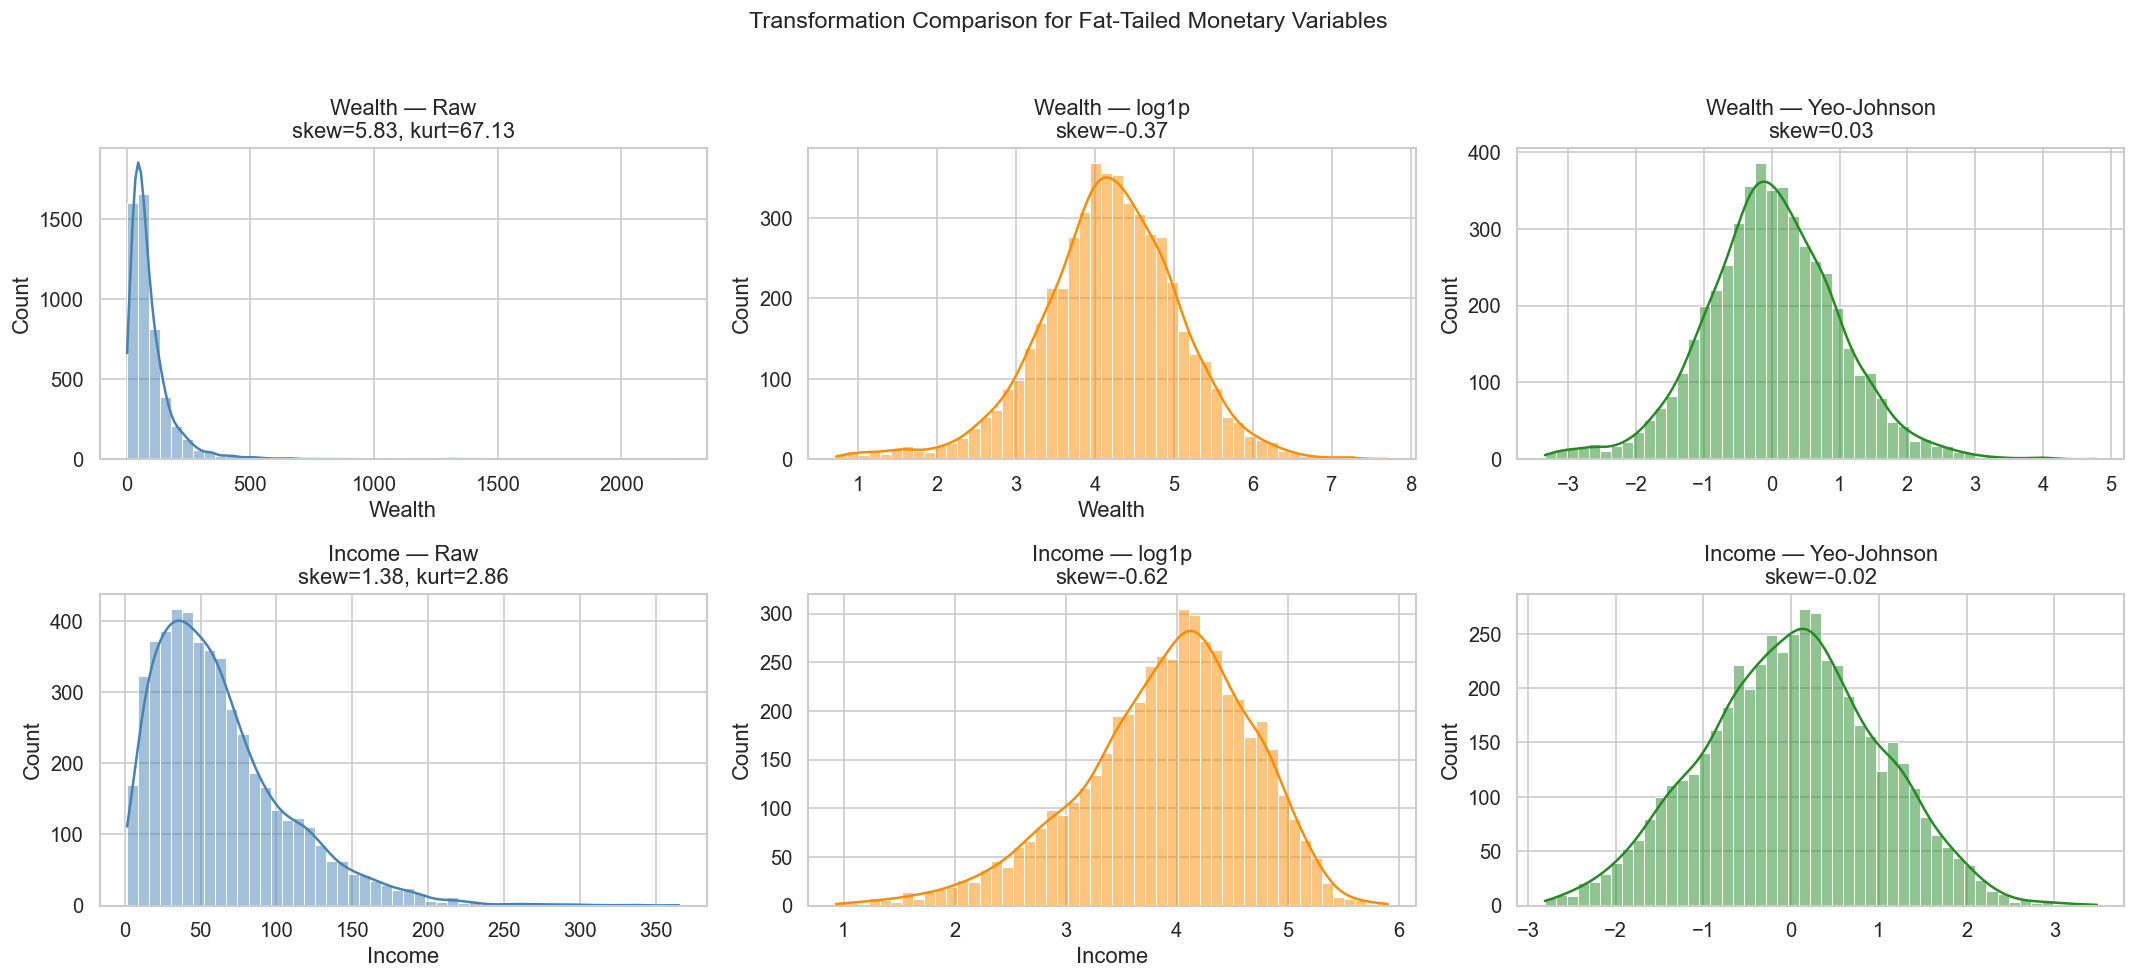

→ log1p provides good normalization; Yeo-Johnson achieves near-zero skewness.
→ We will use log1p in feature engineering (interpretable) and StandardScaler for model input.


In [ ]:
# WEALTH & INCOME TRANSFORMATION COMPARISON
fig, axes = plt.subplots(2, 3, figsize=(18, 8))

for row, feat in enumerate(["Wealth", "Income"]):
    data = df[feat]

    # Raw
    sns.histplot(data, kde=True, ax=axes[row, 0], color="steelblue", bins=50)
    axes[row, 0].set_title(
        f"{feat} — Raw\nskew={data.skew():.2f}, kurt={data.kurtosis():.2f}"
    )

    # Log1p
    log_data = np.log1p(data)
    sns.histplot(log_data, kde=True, ax=axes[row, 1], color="darkorange", bins=50)
    axes[row, 1].set_title(f"{feat} — log1p\nskew={log_data.skew():.2f}")

    # Yeo-Johnson
    pt = PowerTransformer(method="yeo-johnson")
    yj_data = pt.fit_transform(data.values.reshape(-1, 1)).flatten()
    sns.histplot(yj_data, kde=True, ax=axes[row, 2], color="forestgreen", bins=50)
    axes[row, 2].set_title(
        f"{feat} — Yeo-Johnson\nskew={pd.Series(yj_data).skew():.2f}"
    )

plt.suptitle(
    "Transformation Comparison for Fat-Tailed Monetary Variables", fontsize=14, y=1.02
)
plt.tight_layout()
plt.show()

log1p provides good normalization; Yeo-Johnson achieves near-zero skewness.

We will use log1p in feature engineering (interpretable) and StandardScaler for model input.


**Figure explanation — one row per monetary variable (Wealth, Income):**

**Raw distribution (left column):** Shows the original, untransformed values. Both variables exhibit strong positive skew and high kurtosis — the bulk of observations sit in a narrow low range, with a long tail stretching toward much higher values. This shape can cause distance-based models (e.g. KNN, SVM) and gradient-based optimisers to be dominated by extreme values.

**log1p transformation (centre column):** Applying `log(1 + x)` compresses the right tail substantially. The resulting distribution is much closer to bell-shaped, and the skewness value drops considerably. Because the log function is monotonic and interpretable (a one-unit change in log-income corresponds to a multiplicative change in raw income), this is a practical choice for feature engineering.

**Yeo-Johnson transformation (right column):** This is a parametric power transformation that searches for the lambda value minimising skewness. It typically achieves near-zero skewness, producing an almost perfectly symmetric distribution. However, the transformed values lose direct interpretability — they live on an abstract scale rather than a meaningful monetary one.

**Conclusion:** `log1p` offers the best trade-off between normalisation and interpretability, so we adopt it for engineered features. For model input, we additionally apply `StandardScaler` to centre and scale the transformed values.


## 5. Correlation Analysis

We compute both Pearson (linear) and Spearman (monotonic/rank) correlation matrices. Comparing the two helps identify relationships that are real but non-linear — a common situation with financial variables.


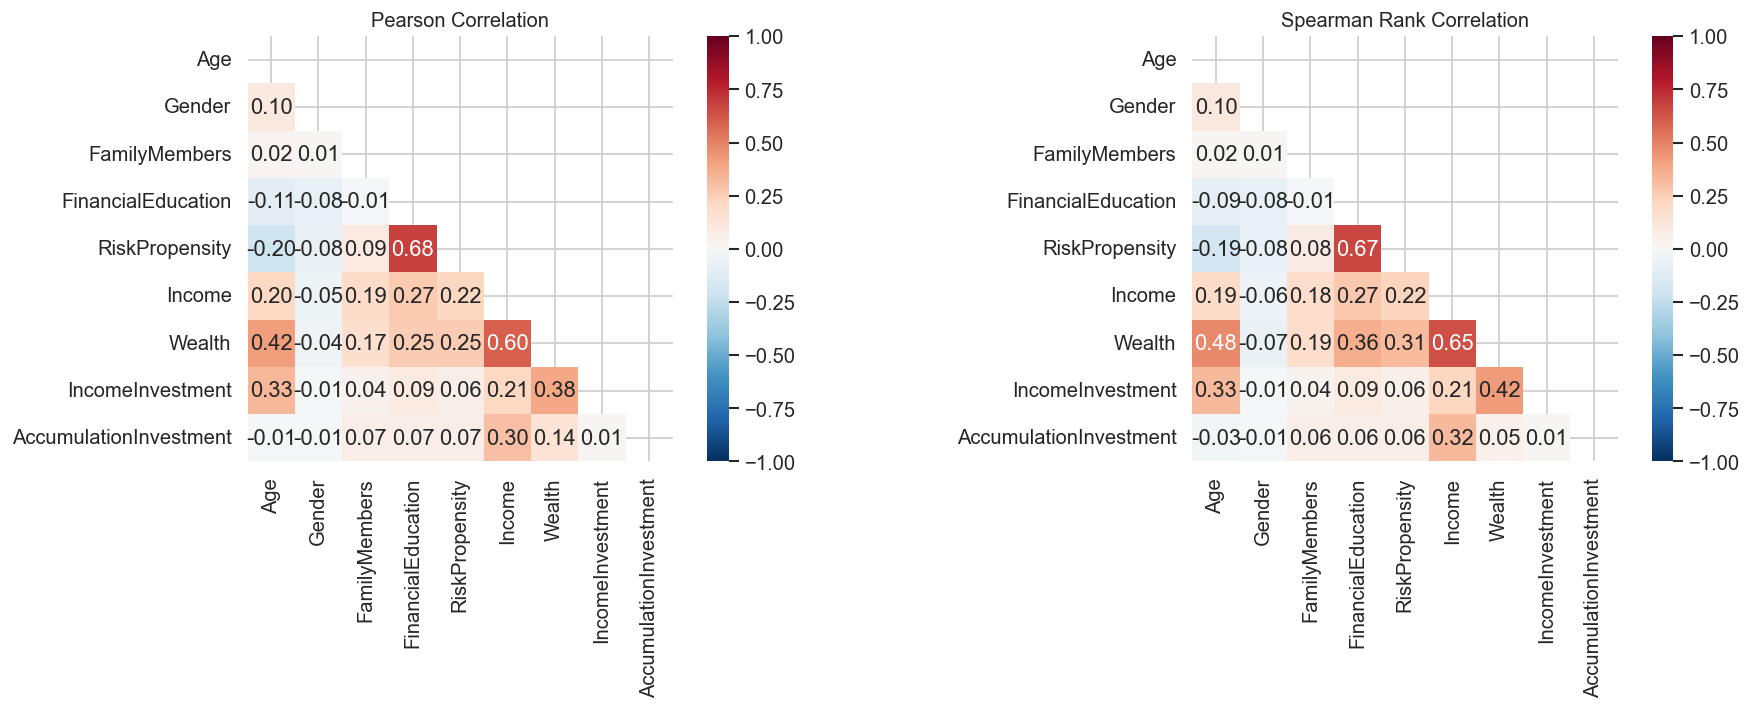

In [9]:
# CORRELATION HEATMAPS (PEARSON + SPEARMAN)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

mask = np.triu(np.ones_like(df.corr(), dtype=bool))

sns.heatmap(
    df.corr(method="pearson"),
    annot=True,
    fmt=".2f",
    cmap="RdBu_r",
    center=0,
    ax=axes[0],
    vmin=-1,
    vmax=1,
    mask=mask,
    square=True,
)
axes[0].set_title("Pearson Correlation", fontsize=12)

sns.heatmap(
    df.corr(method="spearman"),
    annot=True,
    fmt=".2f",
    cmap="RdBu_r",
    center=0,
    ax=axes[1],
    vmin=-1,
    vmax=1,
    mask=mask,
    square=True,
)
axes[1].set_title("Spearman Rank Correlation", fontsize=12)

plt.tight_layout()
plt.show()


**Figure explanation:**

**Pearson correlation (left):** Measures the strength of _linear_ relationships between each pair of variables. Values near +1 or −1 indicate a strong linear association; values near 0 suggest no linear relationship. Look for which features correlate most with the two targets (`IncomeInvestment`, `AccumulationInvestment`). Also pay attention to inter-feature correlations — if two features are highly correlated with each other (e.g. `Income` and `Wealth`), they carry overlapping information, which can affect model stability.

**Spearman rank correlation (right):** Measures _monotonic_ (rank-based) relationships instead of strictly linear ones. This is more robust to outliers and captures associations where one variable consistently increases with another even if the relationship is curved. When a pair shows low Pearson but noticeably higher Spearman correlation, that signals a real but non-linear relationship — meaning tree-based or other flexible models may exploit it better than a linear classifier.

**Reading both together:** Comparing the two matrices side by side helps distinguish truly weak relationships (low in both) from relationships that are real but non-linear (low Pearson, higher Spearman). The upper triangle is masked to avoid visual redundancy since correlation matrices are symmetric.


## 6. Point-Biserial Correlations & Mann-Whitney U Tests

To go beyond visual patterns, we measure the strength and significance of each feature's association with the binary targets. Point-biserial correlation gives effect size; Mann-Whitney U tests whether the distributions of a feature differ significantly between positive and negative cases.


In [10]:
# POINT-BISERIAL CORRELATIONS + MANN-WHITNEY U TESTS
features_list = [
    "Age",
    "Gender",
    "FamilyMembers",
    "FinancialEducation",
    "RiskPropensity",
    "Income",
    "Wealth",
]

print("=" * 80)
print("POINT-BISERIAL CORRELATIONS WITH TARGETS")
print("=" * 80)
for target in ["IncomeInvestment", "AccumulationInvestment"]:
    print(f"\n  {target}:")
    for feat in features_list:
        r, p = pointbiserialr(df[target], df[feat])
        sig = "***" if p < 0.001 else "**" if p < 0.01 else "*" if p < 0.05 else "ns"
        print(f"    {feat:25s}: r={r:+.4f}, p={p:.4e} {sig}")

print("\n" + "=" * 80)
print("MANN-WHITNEY U TESTS (Y=0 vs Y=1)")
print("=" * 80)
for target in ["IncomeInvestment", "AccumulationInvestment"]:
    print(f"\n  {target}:")
    for feat in features_list:
        g0 = df.loc[df[target] == 0, feat]
        g1 = df.loc[df[target] == 1, feat]
        u_stat, p = mannwhitneyu(g0, g1, alternative="two-sided")
        eff_r = 1 - (2 * u_stat) / (len(g0) * len(g1))  # rank-biserial
        print(
            f"    {feat:25s}: U={u_stat:>12,.0f}, p={p:.4e}, r_rb={eff_r:+.3f} "
            f"{'***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else 'ns'}"
        )


POINT-BISERIAL CORRELATIONS WITH TARGETS

  IncomeInvestment:
    Age                      : r=+0.3342, p=8.9367e-131 ***
    Gender                   : r=-0.0137, p=3.3267e-01 ns
    FamilyMembers            : r=+0.0419, p=3.0182e-03 **
    FinancialEducation       : r=+0.0874, p=5.9372e-10 ***
    RiskPropensity           : r=+0.0633, p=7.4280e-06 ***
    Income                   : r=+0.2089, p=2.0009e-50 ***
    Wealth                   : r=+0.3842, p=1.2241e-175 ***

  AccumulationInvestment:
    Age                      : r=-0.0135, p=3.3945e-01 ns
    Gender                   : r=-0.0108, p=4.4589e-01 ns
    FamilyMembers            : r=+0.0666, p=2.4316e-06 ***
    FinancialEducation       : r=+0.0680, p=1.5078e-06 ***
    RiskPropensity           : r=+0.0684, p=1.2823e-06 ***
    Income                   : r=+0.3003, p=9.6936e-105 ***
    Wealth                   : r=+0.1384, p=8.2991e-23 ***

MANN-WHITNEY U TESTS (Y=0 vs Y=1)

  IncomeInvestment:
    Age                      :

**Output explanation:**

**Point-biserial correlations:** For each feature–target pair, the point-biserial coefficient `r` measures the strength and direction of linear association between a continuous feature and a binary target. Values close to 0 mean the feature's average is nearly the same for both target classes; larger absolute values mean the feature shifts meaningfully between classes 0 and 1. The significance markers (`***` for p < 0.001, `**` for p < 0.01, `*` for p < 0.05, `ns` for not significant) indicate whether the observed association is statistically reliable given the sample size. Features with strong, significant correlations to a target are natural candidates for the model to leverage.

**Mann-Whitney U tests:** This is a non-parametric alternative that compares the full distributions (not just means) of a feature between the two target groups. The U statistic and p-value test whether one group tends to have systematically higher values than the other. The rank-biserial correlation `r_rb` is an effect-size measure: values near 0 mean the two groups are nearly identical in rank, while larger absolute values indicate meaningful separation. Features where both the point-biserial and Mann-Whitney tests agree on significance give us the most confidence that a real relationship exists.


## 7. Feature Interactions — Violin Plots by Target

We compare the distribution of key features across target classes using violin plots overlaid with strip plots. This reveals whether a feature creates separation between classes or whether the two groups overlap heavily.


/var/folders/qh/7nh8ljpn5m504tw502bjr4880000gn/T/ipykernel_8760/3676546389.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
/var/folders/qh/7nh8ljpn5m504tw502bjr4880000gn/T/ipykernel_8760/3676546389.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
/var/folders/qh/7nh8ljpn5m504tw502bjr4880000gn/T/ipykernel_8760/3676546389.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
/var/folders/qh/7nh8ljpn5m504tw502bjr4880000gn/T/ipykernel_8760/3676546389.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated 

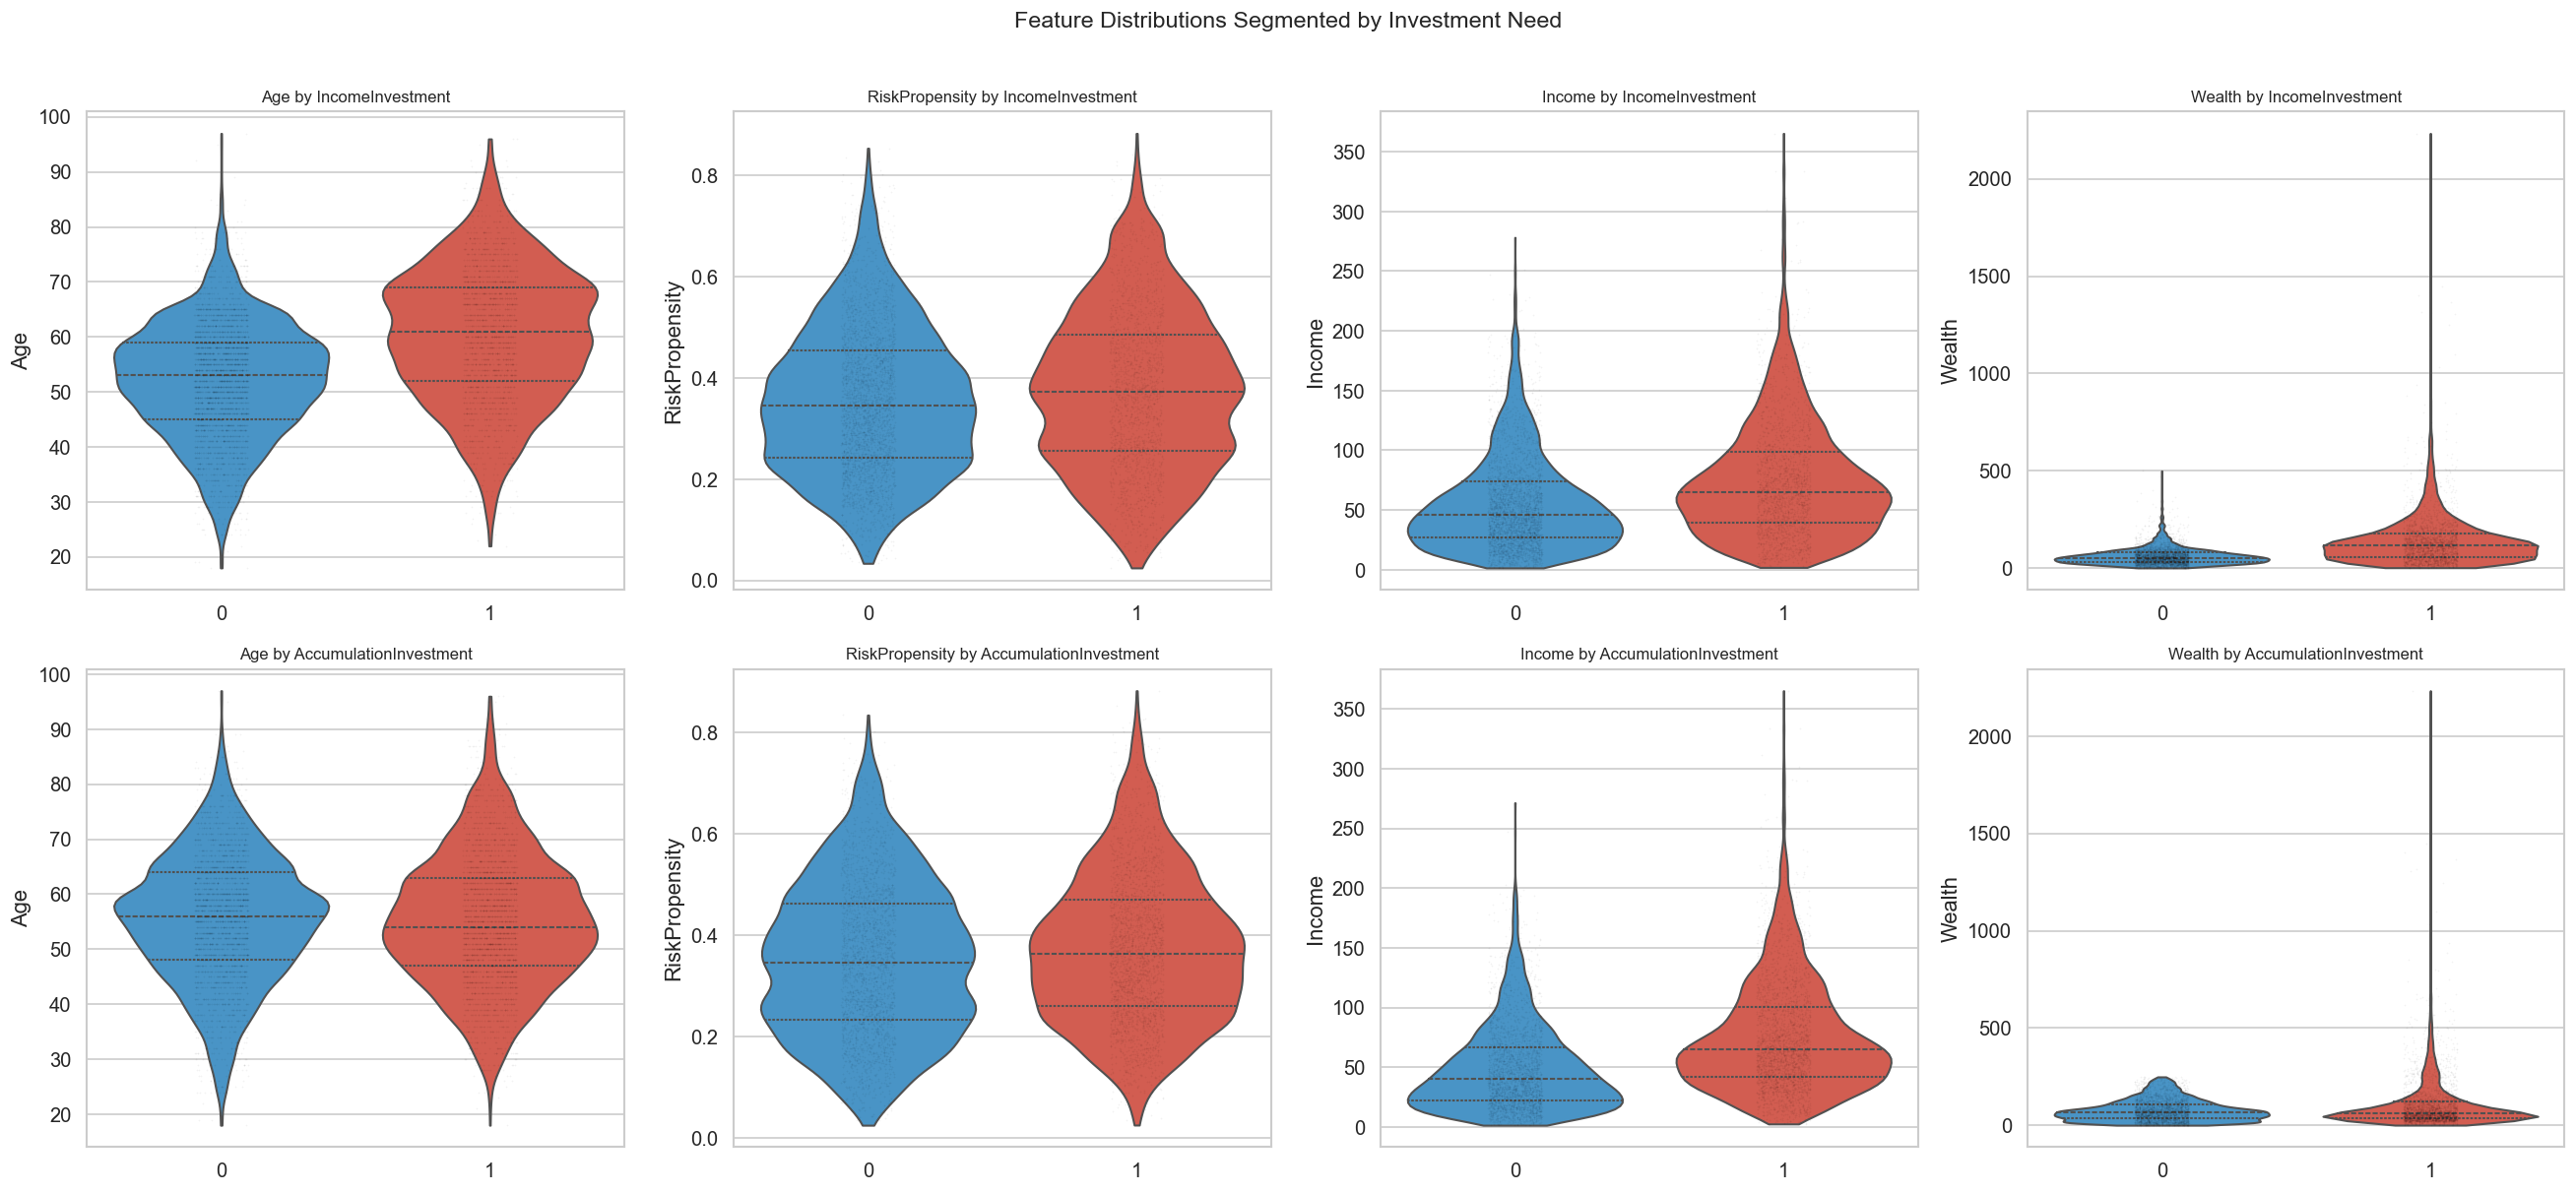

In [11]:
# VIOLIN PLOTS — FEATURE DISTRIBUTIONS BY TARGET
fig, axes = plt.subplots(2, 4, figsize=(22, 10))

for row, target in enumerate(["IncomeInvestment", "AccumulationInvestment"]):
    for col, feat in enumerate(["Age", "RiskPropensity", "Income", "Wealth"]):
        ax = axes[row, col]
        sns.violinplot(
            x=df[target],
            y=df[feat],
            hue=df[target],
            ax=ax,
            palette=["#3498db", "#e74c3c"],
            inner="quartile",
            cut=0,
            bw_adjust=0.8,
            legend=False,
        )
        # Overlay strip plot for granularity
        sns.stripplot(
            x=df[target], y=df[feat], ax=ax, color="black", alpha=0.05, size=1
        )
        ax.set_title(f"{feat} by {target}", fontsize=10)
        ax.set_xlabel("")

plt.suptitle("Feature Distributions Segmented by Investment Need", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()


**Figure explanation — 2×4 grid (rows = targets, columns = features):**

**Top row — IncomeInvestment:** Each subplot shows how a feature (`Age`, `RiskPropensity`, `Income`, `Wealth`) is distributed for clients without an income investment need (class 0, blue) versus clients with one (class 1, red). The violin width represents density — wider sections mean more clients sit at that value. The inner dashed lines mark the quartiles (25th, 50th, 75th percentile). If the two violins have clearly different medians or shapes, the feature carries discriminative power for this target. Overlapping violins mean the feature alone does not strongly separate the classes.

**Bottom row — AccumulationInvestment:** Same layout, but now segmented by the accumulation target. Comparing the two rows reveals whether the same feature is useful for both targets or only one — for example, `Wealth` might shift noticeably for `AccumulationInvestment` but not for `IncomeInvestment`, or vice versa.

**Strip plot overlay (black dots):** The faint individual data points layered on top of each violin give a sense of raw data density, especially in sparse regions where the KDE smoothing in the violin might overstate density. Clusters of dots at extreme values confirm the presence of outliers already detected in the box plots.


## 8. Gender × Target Interaction

We check whether need prevalence varies by gender, and whether family size differs across combined target groups (Kruskal-Wallis test). These interactions can reveal whether demographic segmentation adds predictive value.


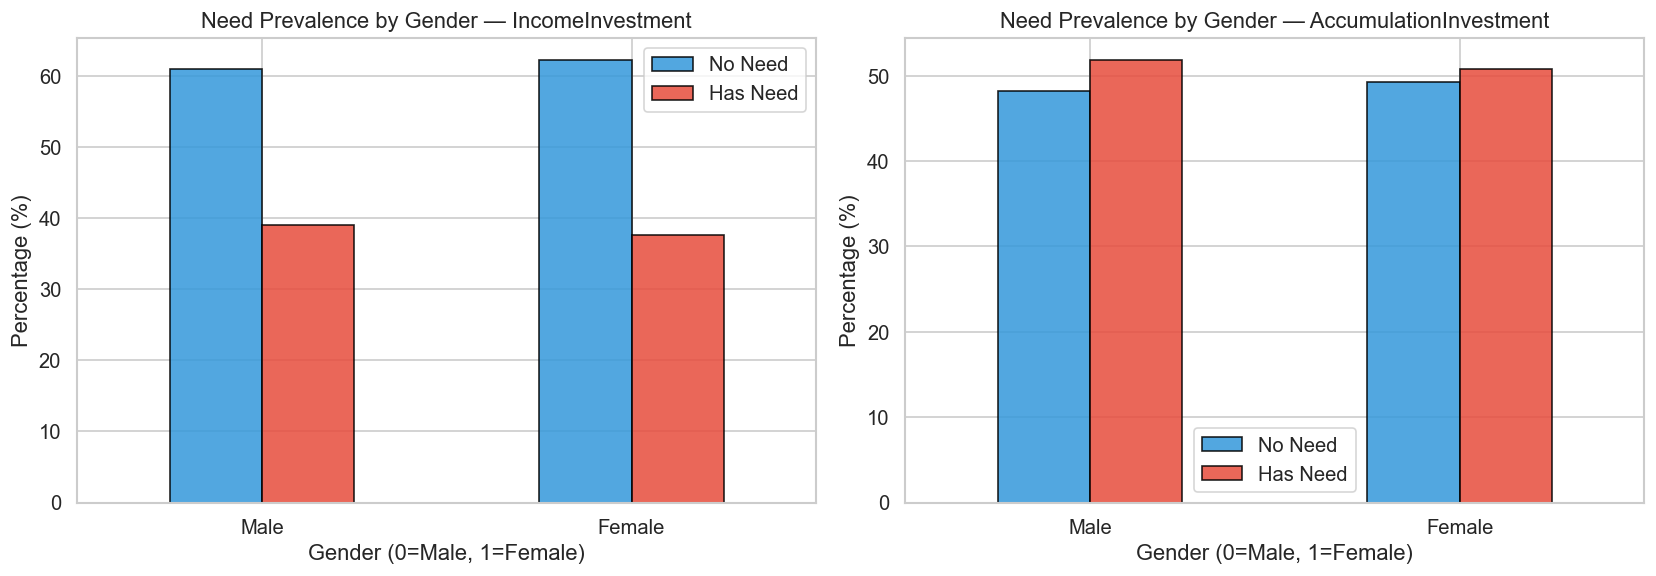

Kruskal-Wallis test (FamilyMembers across need groups): H=28.43, p=2.9561e-06


In [12]:
# GENDER × TARGET INTERACTION ANALYSIS
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, target in zip(axes, ["IncomeInvestment", "AccumulationInvestment"]):
    ct = pd.crosstab(df["Gender"], df[target], normalize="index") * 100
    ct.plot(
        kind="bar", ax=ax, color=["#3498db", "#e74c3c"], edgecolor="black", alpha=0.85
    )
    ax.set_title(f"Need Prevalence by Gender — {target}")
    ax.set_xlabel("Gender (0=Male, 1=Female)")
    ax.set_ylabel("Percentage (%)")
    ax.set_xticklabels(["Male", "Female"], rotation=0)
    ax.legend(["No Need", "Has Need"])

plt.tight_layout()
plt.show()

# Kruskal-Wallis test: do family members differ by combined target group?
df["NeedGroup"] = (
    df["IncomeInvestment"].astype(str) + "_" + df["AccumulationInvestment"].astype(str)
)
groups = [g["FamilyMembers"].values for _, g in df.groupby("NeedGroup")]
h_stat, h_p = kruskal(*groups)
print(
    f"Kruskal-Wallis test (FamilyMembers across need groups): H={h_stat:.2f}, p={h_p:.4e}"
)
df.drop("NeedGroup", axis=1, inplace=True)


**Figure explanation:**

**Bar chart — IncomeInvestment by Gender (left):** Shows the percentage of male (Gender = 0) and female (Gender = 1) clients who do and do not have an income investment need. If both genders have nearly the same proportion of "Has Need" (red bar), gender is not a strong standalone predictor for this target. If one gender shows a noticeably higher red bar, that suggests a demographic-level difference worth exploring as a feature or interaction term.

**Bar chart — AccumulationInvestment by Gender (right):** Same comparison for the accumulation target. Again, look for whether the red/blue split changes meaningfully between male and female clients. Together, the two charts tell us whether gender plays a different role for each of the two financial needs.

**Kruskal-Wallis test (printed output):** This test groups clients into four combined need categories (no need for either, income only, accumulation only, both) and checks whether `FamilyMembers` differs across these groups. A significant result (low p-value) would suggest that household size is associated with the type of financial need a client has, which could be useful as an interaction feature in the model.


## 9. Dimensionality Reduction — PCA

As a final diagnostic, we apply PCA to the standardised feature matrix. The scree plot shows how variance is distributed across components, and the 2D projections let us visually assess whether the target classes form separable clusters in reduced space. PCA here is an exploratory tool — not a modelling decision.


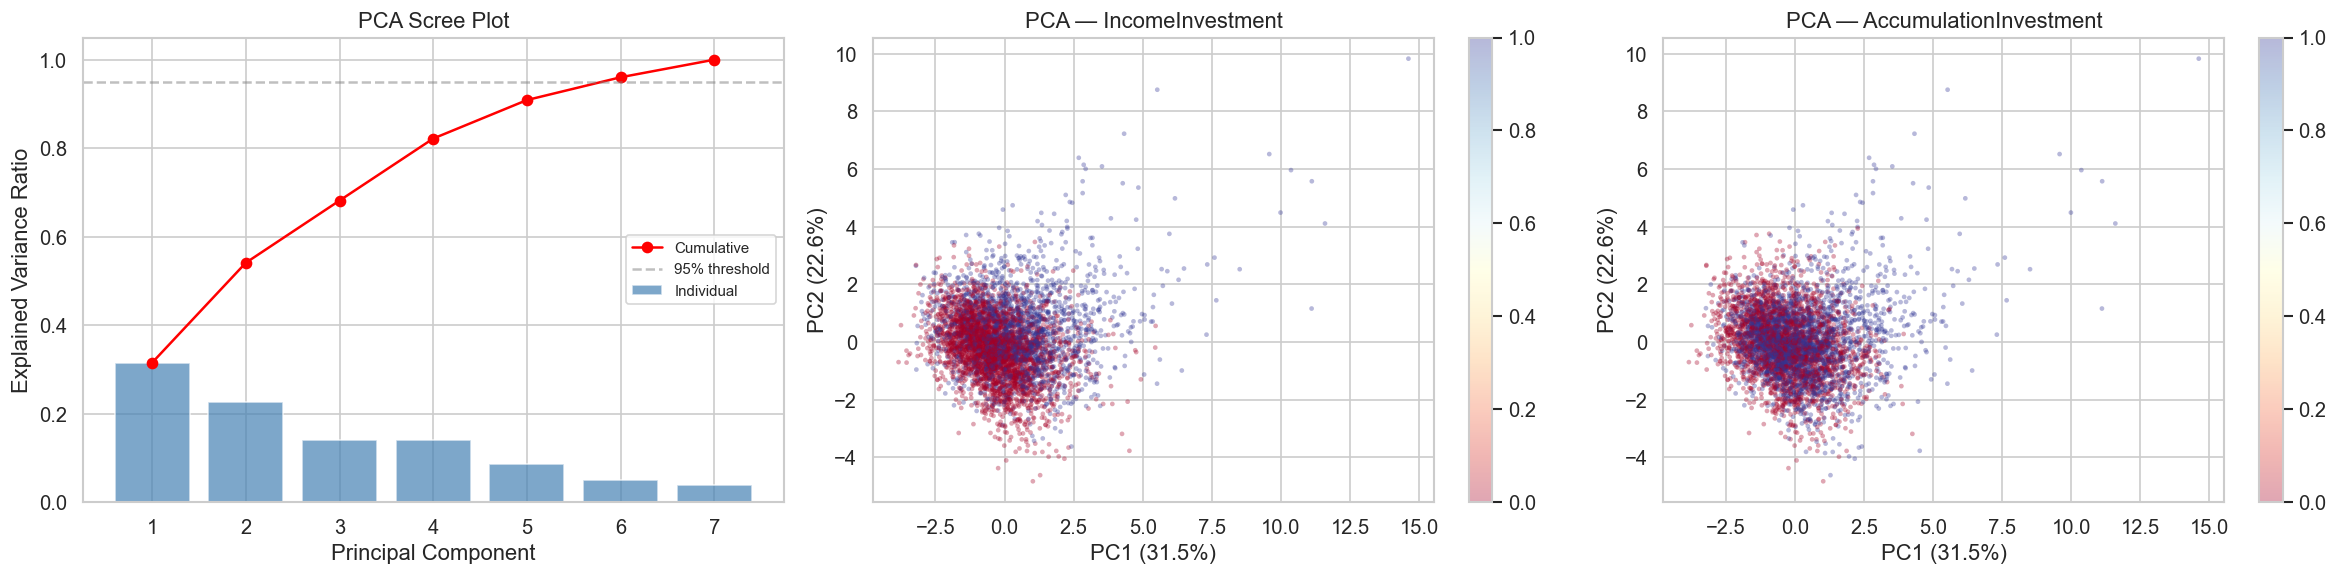

PCA explained variance (2 components): 54.1%
Components for 95% variance: 6


In [13]:
# PCA ANALYSIS + SCREE PLOT
X_viz = df[features_list].copy()
scaler_viz = StandardScaler()
X_scaled_viz = scaler_viz.fit_transform(X_viz)

# Full PCA
pca_full = PCA(random_state=42).fit(X_scaled_viz)

fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# Scree plot
ax = axes[0]
cumvar = np.cumsum(pca_full.explained_variance_ratio_)
ax.bar(
    range(1, len(pca_full.explained_variance_ratio_) + 1),
    pca_full.explained_variance_ratio_,
    alpha=0.7,
    color="steelblue",
    label="Individual",
)
ax.plot(range(1, len(cumvar) + 1), cumvar, "ro-", label="Cumulative")
ax.axhline(y=0.95, color="gray", ls="--", alpha=0.5, label="95% threshold")
ax.set_xlabel("Principal Component")
ax.set_ylabel("Explained Variance Ratio")
ax.set_title("PCA Scree Plot")
ax.legend(fontsize=9)

# 2D PCA colored by each target
pca_2d = PCA(n_components=2, random_state=42)
X_pca = pca_2d.fit_transform(X_scaled_viz)

for ax, target in zip(axes[1:], ["IncomeInvestment", "AccumulationInvestment"]):
    scatter = ax.scatter(
        X_pca[:, 0],
        X_pca[:, 1],
        c=df[target],
        cmap="RdYlBu",
        alpha=0.35,
        s=8,
        edgecolors="none",
    )
    ax.set_xlabel(f"PC1 ({pca_2d.explained_variance_ratio_[0]:.1%})")
    ax.set_ylabel(f"PC2 ({pca_2d.explained_variance_ratio_[1]:.1%})")
    ax.set_title(f"PCA — {target}")
    plt.colorbar(scatter, ax=ax)

plt.tight_layout()
plt.show()

print(
    f"PCA explained variance (2 components): {pca_2d.explained_variance_ratio_.sum():.1%}"
)
n_95 = np.argmax(cumvar >= 0.95) + 1
print(f"Components for 95% variance: {n_95}")


**Figure explanation:**

**Scree plot (left):** Each blue bar shows the fraction of total variance captured by one principal component, and the red line tracks the cumulative sum. The grey dashed line marks the 95 % threshold. If the first two or three components already capture most of the variance, the effective dimensionality of the dataset is low — meaning the features contain a lot of redundant or correlated information. If variance is spread evenly across many components, each feature contributes unique information. The number of components needed to reach 95 % is printed below the figure.

**2D scatter — IncomeInvestment (centre):** Each point is one client, projected onto the first two principal components. Colour represents the target class. If the two colours form distinct regions or clusters, the classes are separable in the top-2 PCA directions — meaning even a simple linear classifier might work. If the colours are thoroughly mixed, linear separation in reduced dimensions is weak, and we should expect to need non-linear models (e.g. tree-based ensembles, neural networks) that can operate in the full feature space.

**2D scatter — AccumulationInvestment (right):** Same projection, coloured by the second target. Comparing the two scatter plots lets us see whether one target has better structure in PCA space than the other, which can foreshadow relative modelling difficulty.

**Overall takeaway:** PCA here is purely diagnostic. The scree plot tells us about feature redundancy, and the scatter plots give a quick visual sanity check of class separability. Neither replaces proper modelling — they simply inform expectations.


---

## Summary

Key takeaways from this EDA:

- Both targets are moderately imbalanced, so evaluation should go beyond accuracy (F1, AUC, precision-recall).
- `Income` and `Wealth` are heavily right-skewed; `log1p` is a good normalising transformation.
- Several features show statistically significant associations with the targets, though effect sizes are modest.
- PCA confirms that the feature space is relatively low-dimensional but classes are not linearly separable in 2D — non-linear models are warranted.

These findings directly inform the feature engineering, model selection, and evaluation strategy in the main modelling notebook.


## 10. Outlier Detection — Isolation Forest


In this project, the use of Isolation Forest to flag outliers remains appropriate despite the presence of a categorical variable, as the only categorical feature included in the dataset is Gender, which is binary (encoded as 0 and 1). Unlike multi-class categorical variables, binary variables do not introduce misleading ordinal relationships when used in tree-based methods, since splits such as “Gender < 0.5” simply separate the two categories in a meaningful way. Furthermore, the majority of the features in the dataset are numerical, which aligns well with the assumptions underlying Isolation Forest, as it relies on random splits in a numerical feature space to isolate observations. As a result, the inclusion of a single binary variable does not significantly distort the geometry of the data nor the anomaly detection process. Therefore, Isolation Forest can be reliably applied in this context to identify atypical client profiles without introducing substantial bias.


Here, we choose to classify the 5% lowest scores as outliers.


In [14]:
# Dataclass used to store the cleaned and prepared dataset
@dataclass
class PreparedFeatures:
    # Final prepared dataset of features after preprocessing
    X: pd.DataFrame

    # Metadata associated with this dataset (feature descriptions, etc.)
    features_metadata_df: pd.DataFrame

    # List of numerical columns kept in the dataset
    numeric_cols: List[str]

    # List of categorical columns kept in the dataset
    categorical_cols: List[str]

    # Columns that have zero variance
    removed_zero_variance_cols: List[str]

    # Columns with very low variance
    near_zero_variance_cols: List[str]

    # Audit log describing the preprocessing steps that were applied
    audit_lines: List[str]


@dataclass
class PreparedTargets:
    # Final prepared dataset of targets values after preprocessing
    Y: pd.DataFrame

    # Metadata associated with this dataset (feature descriptions, etc.)
    targets_metadata_df: pd.DataFrame

    # List of indexes retained in the dataset after removing rows with missing IncomeInvestment and AccumulationInvest values
    kept_index: pd.Index

    # number of lines with NaN value
    dropped_rows_missing_target: int

    # Audit log describing the preprocessing steps that were applied
    audit_lines: List[str]


@dataclass
class OutlierDetectionResult:
    # Dataset of features after potentially removing the outliers
    X_inliers: pd.DataFrame

    # Dataset of target values after potentially removing the outliers
    Y_inliers: pd.DataFrame

    # Column associating 1 if the point is considered normal, -1 otherwise
    full_outlier_labels: pd.Series

    # Anomaly score for each observation
    full_anomaly_scores: pd.Series

    # Number of outliers detected
    outlier_count: int

    # Porportion of outliers
    outlier_rate: float

    # Audit log describing the preprocessing steps that were applied
    audit_lines: List[str]

The following code allows you to create two new datasets, one containing all the features and customer data, the other containing the target variables


In [15]:
def split_features_and_targets(
    data: pd.DataFrame, target_cols: List[str] = TARGET_COLS
) -> Tuple[pd.DataFrame, pd.DataFrame]:

    Y = data[target_cols].copy()

    drop_cols = target_cols.copy()
    X = data.drop(columns=drop_cols, errors="ignore").copy()

    return X, Y

In [16]:
X, Y = split_features_and_targets(data=needs_df)

targets_metadata_df = metadata_df[
    metadata_df["Metadata"].isin(TARGET_COLS)
].reset_index(drop=True)

features_metadata_df = metadata_df[
    ~metadata_df["Metadata"].isin(TARGET_COLS)
].reset_index(drop=True)

In [17]:
features_metadata_df.head()

,Metadata,Unnamed: 1
0,Clients,NaN
1,ID,Numerical ID
2,Age,"Age, in years"
3,Gender,"Gender (Female = 1, Male = 0)"
4,FamilyMembers,Number of components


In [18]:
targets_metadata_df.head()

,Metadata,Unnamed: 1
0,IncomeInvestment,Boolean variable for Income investment; 1 = Hi...
1,AccumulationInvestment,Boolean variable for Accumulation/growth inves...


In [19]:
X.head()

,ID,Age,Gender,FamilyMembers,FinancialEducation,RiskPropensity,Income,Wealth
0,1,60,0,2,0.228685,0.233355,68.181525,53.260067
1,2,78,0,2,0.358916,0.170911,21.807595,135.550048
2,3,33,1,2,0.317515,0.249703,23.252747,66.303678
3,4,69,1,4,0.767685,0.654597,166.189034,404.997689
4,5,58,0,3,0.429719,0.349039,21.186723,58.911930


In [20]:
Y.head()

,IncomeInvestment,AccumulationInvestment
0,0,1
1,1,0
2,0,1
3,1,1
4,0,0


In [21]:
# Detect different forms of missing values and replaces them with np.nan
def normalize_missing_tokens(df: pd.DataFrame) -> pd.DataFrame:
    tokens = {"", " ", "NA", "N/A", "na", "n/a", "null", "None", "none", "-", "--"}
    out = df.copy()
    for col in out.columns:
        if out[col].dtype == object:
            out[col] = out[col].replace(list(tokens), np.nan)
    return out


# Detect whether a feature has near-zero variance
def detect_near_zero_variance(series: pd.Series) -> bool:
    s = series.dropna()
    counts = s.value_counts()

    # Compute the ratio between the most frequent and second most frequent values
    freq_ratio = counts.iloc[0] / max(counts.iloc[1], 1)

    # Compute the ratio between the number of different values and the total number of observations used to measure the diversity of values in this feature
    pct_unique = s.nunique() / len(s)
    return (freq_ratio >= 20) and (pct_unique <= 0.10)


def clean_and_audit_data(
    data: pd.DataFrame,
    features_metadata_df: pd.DataFrame,
    categorical_cols: List[str] = CATEGORICAL_COLS,
    numeric_cols: List[str] = NUMERIC_COLS,
    value_maps: Dict[str, Dict[int, str]] = VALUE_MAPS,
) -> PreparedFeatures:
    # Initialize an audit log to keep track of all cleaning steps
    audit_lines: List[str] = []

    # Create a working copy of the dataset and standardize missing-value tokens
    df = normalize_missing_tokens(data.copy())

    # Start audit report
    audit_lines.append("DATA AUDIT")
    audit_lines.append("=" * 80)
    audit_lines.append(f"Initial X shape (dataset of features): {df.shape}")

    # Remove fully duplicated rows
    exact_dupes = int(df.duplicated().sum())
    if exact_dupes > 0:
        df = df.drop_duplicates().copy()
    audit_lines.append(f"Exact duplicate rows removed: {exact_dupes}")

    # Remove duplicated IDs, keeping only the first occurrence
    duplicate_ids = int(df["ID"].duplicated().sum())
    if duplicate_ids > 0:
        df = df.drop_duplicates(subset=["ID"], keep="first").copy()
    audit_lines.append(f"Duplicate IDs removed: {duplicate_ids}")

    # Delete the columns 'ID' that doesn't contains any usefull information for the clustering
    df = df.drop(columns=["ID"])

    # Identify categorical columns
    # Identify numeric columns by excluding ID and categorical columns
    categorical_cols = [c for c in categorical_cols if c in df.columns]
    numeric_cols = [c for c in numeric_cols if c in df.columns]

    # Convert columns to numeric (for instance "2" to 2). Invalid values become NaN
    for col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

    # Validate categorical codes against allowed values defined in VALUE_MAPS
    # All invalid values become: NaN
    audit_lines.append("Invalid categorical codes replaced with missing values:")
    for col in categorical_cols:
        allowed = set(value_maps[col].keys()) if col in value_maps else None
        invalid_mask = ~df[col].isin(allowed) & df[col].notna()
        invalid_count = int(invalid_mask.sum())
        if invalid_count > 0:
            df.loc[invalid_mask, col] = np.nan
        audit_lines.append(f"  - {col}: {invalid_count}")

    # Record missing values before imputation
    audit_lines.append("Missing values before imputation:")
    for col, val in df.isna().sum().items():
        audit_lines.append(f"  - {col}: {int(val)}")

    # Impute missing numeric values with the median
    for col in numeric_cols:
        if df[col].isna().any():
            df[col] = df[col].fillna(df[col].median())

    # Impute missing categorical values with the most frquence value taken
    # If this value doesn't exist, it uses a fallback value defined from the allowed categories (VALUE_MAPS)
    # Finaly convert the entire column to ensure a consistent format usable by algorithms
    for col in categorical_cols:
        if df[col].isna().any():
            mode_value = df[col].mode(dropna=True)
            fallback = sorted(value_maps[col].keys())[0]
            fill_value = int(mode_value.iloc[0]) if not mode_value.empty else fallback
            df[col] = df[col].fillna(fill_value)

        df[col] = df[col].astype(int)

    # Record missing values after imputation
    audit_lines.append("Missing values after imputation:")
    for col, val in df.isna().sum().items():
        audit_lines.append(f"  - {col}: {int(val)}")

    # Detect zero-variance and near-zero-variance features
    removed_zero_variance_cols: List[str] = []
    near_zero_variance_cols: List[str] = []

    # Iterate through the columns
    # Save them that contained only a single value (and therefore having a variance of 0) in the list removed_zero_variance_cols
    # Save them that detecte as "near zero variance" in the list near_zero_variance_cols
    for col in df.columns:
        if df[col].nunique(dropna=False) <= 1:
            removed_zero_variance_cols.append(col)
        elif detect_near_zero_variance(df[col]):
            near_zero_variance_cols.append(col)

    # Remove zero-variance columns
    if removed_zero_variance_cols:
        df = df.drop(columns=removed_zero_variance_cols).copy()

    # Remove near-zero-variance columns
    if near_zero_variance_cols:
        df = df.drop(columns=near_zero_variance_cols).copy()

    audit_lines.append(
        "Zero-variance columns removed: "
        + (
            ", ".join(removed_zero_variance_cols)
            if removed_zero_variance_cols
            else "none"
        )
    )
    audit_lines.append(
        "Near-zero-variance columns removed: "
        + (", ".join(near_zero_variance_cols) if near_zero_variance_cols else "none")
    )

    # Update column lists after removing zero-variance and near-zero-variance columns
    categorical_cols = [
        c for c in categorical_cols if c not in removed_zero_variance_cols
    ]
    numeric_cols = [c for c in numeric_cols if c not in removed_zero_variance_cols]

    # Compute absolute correlation matrix for numeric features
    if numeric_cols:
        corr = df[numeric_cols].corr().abs()
        high_corr = []

        for i in range(len(corr.columns)):
            for j in range(i + 1, len(corr.columns)):
                if corr.iloc[i, j] >= 0.85:
                    high_corr.append(
                        (corr.index[i], corr.columns[j], float(corr.iloc[i, j]))
                    )

        if high_corr:
            audit_lines.append(
                "High-correlation numeric pairs flagged (not auto-removed):"
            )
            for a, b, r in high_corr:
                audit_lines.append(f"  - {a} vs {b}: {r:.3f}")
        else:
            audit_lines.append(
                "High-correlation numeric pairs flagged: none above 0.85"
            )
    else:
        audit_lines.append(
            "High-correlation numeric pairs flagged: no numeric columns available"
        )

    audit_lines.append(f"Final shape after cleaning: {df.shape}")

    return PreparedFeatures(
        X=df,
        features_metadata_df=features_metadata_df,
        numeric_cols=numeric_cols,
        categorical_cols=categorical_cols,
        removed_zero_variance_cols=removed_zero_variance_cols,
        near_zero_variance_cols=near_zero_variance_cols,
        audit_lines=audit_lines,
    )

Binary target processing :


In [22]:
def prepare_binary_targets(
    data: pd.DataFrame,
    targets_metadata_df: pd.DataFrame,
    target_cols: List[str] = TARGET_COLS,
    value_maps: Dict[str, Dict[int, str]] = VALUE_MAPS,
) -> PreparedTargets:
    # Initialize an audit log to keep track of all cleaning steps
    audit_lines: List[str] = []

    # Create a working copy of the dataset and standardize missing-value tokens
    df = normalize_missing_tokens(data.copy())

    # Start audit report
    audit_lines.append("DATA AUDIT")
    audit_lines.append("=" * 80)
    audit_lines.append(f"Initial Y shape (dataset of targets): {df.shape}")

    audit_lines.append(f"Invalid target codes replaced with missing values")
    for col in df.columns:
        # Convert columns to numeric (for instance "2" to 2). Invalid values become NaN
        df[col] = pd.to_numeric(df[col], errors="coerce")

        # Validate values against allowed values defined in VALUE_MAPS
        # All invalid values become: NaN
        allowed = set(value_maps[col].keys())
        invalid_mask = ~df[col].isin(allowed) & df[col].notna()
        invalid_count = int(invalid_mask.sum())
        if invalid_count > 0:
            df.loc[invalid_mask, col] = np.nan

        audit_lines.append(f"  - {col}: {invalid_count}")

    audit_lines.append("Missing values in targets before filtering:")
    for col, val in df.isna().sum().items():
        audit_lines.append(f"  - {col}: {int(val)}")

    # Remove the lines where a target is missing
    mask_complete_targets = df.notna().all(axis=1)

    # number of lines with NaN value
    dropped_rows = int((~mask_complete_targets).sum())

    df = df.loc[mask_complete_targets].copy()

    # List of retained indexes
    kept_index = df.index

    # Conversion finale en int
    for col in df.columns:
        df[col] = df[col].astype(int)

    audit_lines.append(f"Rows dropped because of missing target(s): {dropped_rows}")
    audit_lines.append(f"Final y shape after filtering: {df.shape}")

    return PreparedTargets(
        Y=df,
        targets_metadata_df=targets_metadata_df,
        kept_index=kept_index,
        dropped_rows_missing_target=dropped_rows,
        audit_lines=audit_lines,
    )

In [23]:
prepared_Y = prepare_binary_targets(data=Y, targets_metadata_df=targets_metadata_df)

# We filter raw X based on the rows retained in Y
X_filtered = X.loc[prepared_Y.kept_index].copy()

prepared_X = clean_and_audit_data(
    data=X_filtered, features_metadata_df=features_metadata_df
)

# Sécurité finale : on réaligne Y sur les lignes réellement conservées dans X
X_clean = prepared_X.X
Y_clean = prepared_Y.Y.loc[X_clean.index].copy()

In [24]:
X_clean.head()

,Age,Gender,FamilyMembers,FinancialEducation,RiskPropensity,Income,Wealth
0,60,0,2,0.228685,0.233355,68.181525,53.260067
1,78,0,2,0.358916,0.170911,21.807595,135.550048
2,33,1,2,0.317515,0.249703,23.252747,66.303678
3,69,1,4,0.767685,0.654597,166.189034,404.997689
4,58,0,3,0.429719,0.349039,21.186723,58.911930


In [25]:
Y_clean.head()

,IncomeInvestment,AccumulationInvestment
0,0,1
1,1,0
2,0,1
3,1,1
4,0,0


In [26]:
print("\n".join(prepared_X.audit_lines))
print()
print("\n".join(prepared_Y.audit_lines))

DATA AUDIT
Initial X shape (dataset of features): (5000, 8)
Exact duplicate rows removed: 0
Duplicate IDs removed: 0
Invalid categorical codes replaced with missing values:
  - Gender: 0
Missing values before imputation:
  - Age: 0
  - Gender: 0
  - FamilyMembers: 0
  - FinancialEducation: 0
  - RiskPropensity: 0
  - Income: 0
  - Wealth: 0
Missing values after imputation:
  - Age: 0
  - Gender: 0
  - FamilyMembers: 0
  - FinancialEducation: 0
  - RiskPropensity: 0
  - Income: 0
  - Wealth: 0
Zero-variance columns removed: none
Near-zero-variance columns removed: none
High-correlation numeric pairs flagged: none above 0.85
Final shape after cleaning: (5000, 7)

DATA AUDIT
Initial Y shape (dataset of targets): (5000, 2)
Invalid target codes replaced with missing values
  - IncomeInvestment: 0
  - AccumulationInvestment: 0
Missing values in targets before filtering:
  - IncomeInvestment: 0
  - AccumulationInvestment: 0
Rows dropped because of missing target(s): 0
Final y shape after filt

## 11. Outlier Detection & Analysis


Now we focus specifically on the two targets:

- `IncomeInvestment`
- `AccumulationInvestment`

More especially, we will checs:

- how many positive vs negative cases we have for each target

This is essential because if one class largely dominates, a model can achieve high accuracy by simply predicting the majority class, without actually learning meaningful patterns.

- whether one target is more imbalanced than the other

higher imbalance generally makes the classification task harder, especially for the minority class. In such cases, accuracy becomes unreliable, and metrics like precision, recall, or F1-score are more appropriate.

- whether the targets are statistically associated

A strong association suggests overlapping investment behaviors and supports a joint modeling approach, while a weak association indicates that the targets capture different profiles and may require separate modeling


In [27]:
def detect_outliers_isolation_forest(
    X: pd.DataFrame,
    Y: pd.DataFrame,
    numeric_cols: List[str] = NUMERIC_COLS,
    score_percentile: float = 5.0,
    n_estimators: int = 300,
    random_state: int = 42,
    remove_outliers: bool = False,
) -> OutlierDetectionResult:

    # Detect atypical observations in X with Isolation Forest, then possibly remove them from X and Y
    audit_lines: List[str] = []
    audit_lines.append("OUTLIER DETECTION WITH ISOLATION FOREST")
    audit_lines.append("=" * 80)
    audit_lines.append(f"Input X shape: {X.shape}")
    audit_lines.append(f"Score percentile threshold: {score_percentile}")
    audit_lines.append(f"n_estimators: {n_estimators}")

    # Standardize the numerical variables (excluding gender)
    X_scaled = X.copy()
    scaler = StandardScaler()
    X_scaled[numeric_cols] = scaler.fit_transform(X[numeric_cols])

    iso = IsolationForest(n_estimators=n_estimators, random_state=random_state)
    iso.fit(X_scaled)

    # Returns an anomaly score
    # The lower the score, the more suspicious the observation.
    scores = iso.decision_function(X_scaled)

    # Convert scores to pandas Series
    scores_series = pd.Series(scores, index=X.index, name="AnomalyScore")

    # Threshold based on the score distribution
    score_threshold = np.percentile(scores, score_percentile)

    # Build labels manually from the threshold
    # -1: atypical observation
    #  1: normal observation
    labels = np.where(scores <= score_threshold, -1, 1)
    labels_series = pd.Series(labels, index=X.index, name="OutlierLabel")

    outlier_count = int((labels_series == -1).sum())
    outlier_rate = outlier_count / len(X)

    audit_lines.append(f"Score threshold used: {score_threshold:.6f}")
    audit_lines.append(f"Outliers detected: {outlier_count}")
    audit_lines.append(f"Outlier rate: {outlier_rate:.2%}")

    if remove_outliers:
        inlier_mask = labels_series == 1
        # keep only the normal lines in X and Y
        X_inliers = X.loc[inlier_mask].copy()
        Y_inliers = Y.loc[inlier_mask].copy()
        audit_lines.append("Outliers removed from returned datasets: yes")
    else:
        X_inliers = X.copy()
        Y_inliers = Y.copy()
        audit_lines.append("Outliers removed from returned datasets: no")

    return OutlierDetectionResult(
        X_inliers=X,
        Y_inliers=Y,
        full_outlier_labels=labels_series,
        full_anomaly_scores=scores_series,
        outlier_count=outlier_count,
        outlier_rate=outlier_rate,
        audit_lines=audit_lines,
    )

In [28]:
outlier_result = detect_outliers_isolation_forest(X=X_clean, Y=Y_clean)

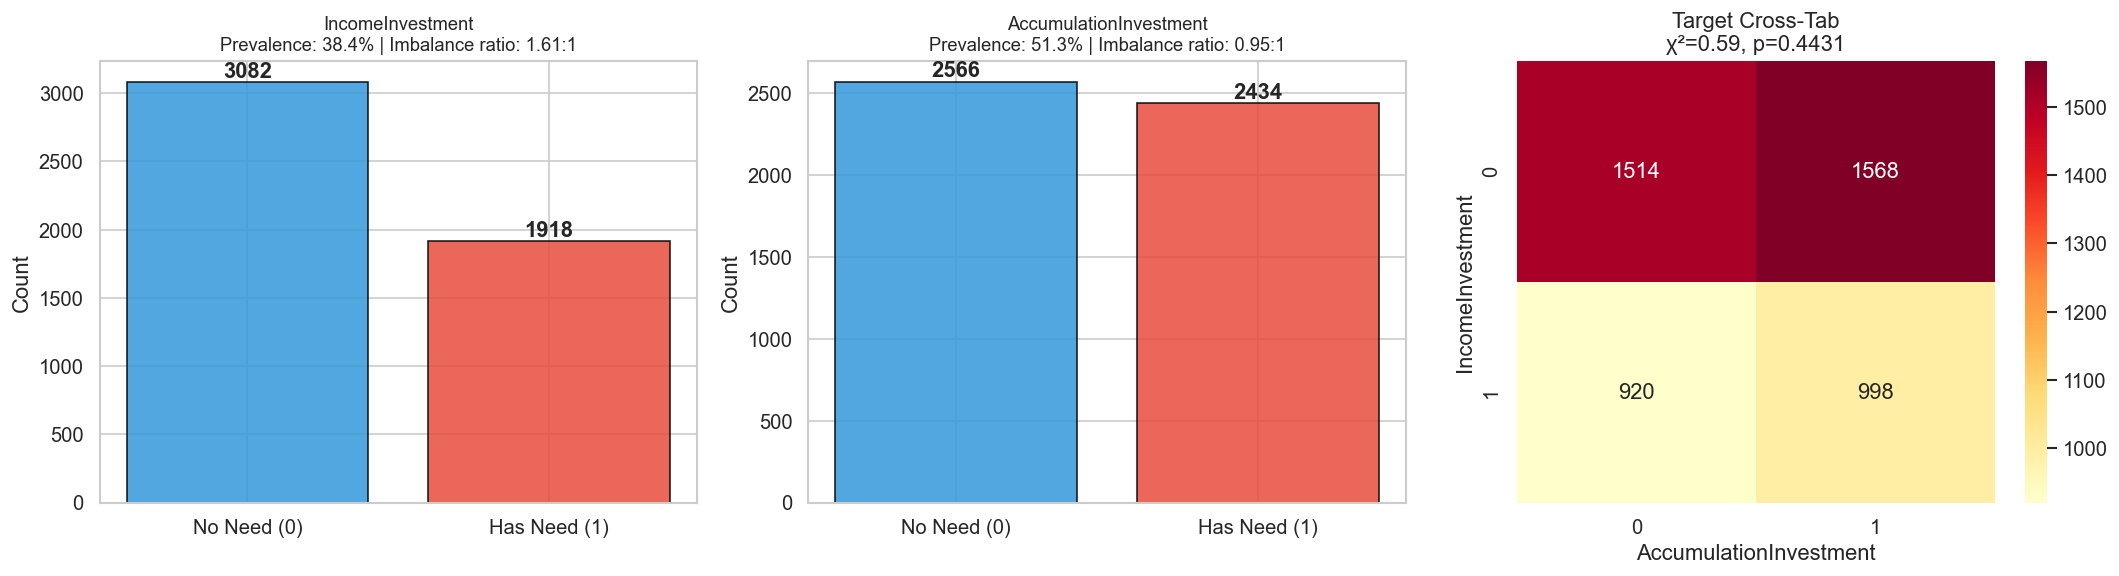

Chi-squared independence test: χ²=0.59, p=4.4306e-01
We consider that: targets are independent (α=0.05)


In [29]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, target in zip(axes[:2], ["IncomeInvestment", "AccumulationInvestment"]):
    counts = outlier_result.Y_inliers[target].value_counts()
    ratio = counts[1] / len(outlier_result.Y_inliers)
    colors = ["#3498db", "#e74c3c"]
    bars = ax.bar(
        ["No Need (0)", "Has Need (1)"],
        counts.values,
        color=colors,
        edgecolor="black",
        alpha=0.85,
    )
    ax.set_title(
        f"{target}\nPrevalence: {ratio:.1%} | Imbalance ratio: {counts[0] / counts[1]:.2f}:1",
        fontsize=11,
    )
    ax.set_ylabel("Count")
    for bar, v in zip(bars, counts.values):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            v + 30,
            str(v),
            ha="center",
            fontweight="bold",
        )


# Cross-tabulation heatmap
ct = pd.crosstab(
    outlier_result.Y_inliers["IncomeInvestment"],
    outlier_result.Y_inliers["AccumulationInvestment"],
)
chi2, p, dof, expected = chi2_contingency(ct)
sns.heatmap(ct, annot=True, fmt="d", cmap="YlOrRd", ax=axes[2])
axes[2].set_title(f"Target Cross-Tab\nχ²={chi2:.2f}, p={p:.4f}")
axes[2].set_xlabel("AccumulationInvestment")
axes[2].set_ylabel("IncomeInvestment")

plt.tight_layout()
plt.show()

print(f"Chi-squared independence test: χ²={chi2:.2f}, p={p:.4e}")
print(
    f"We consider that: targets are {'associated' if p < 0.05 else 'independent'} (α=0.05)"
)

In [30]:
print("\n".join(outlier_result.audit_lines))

# Jeux finaux pour le modèle
X_final = outlier_result.X_inliers
Y_final = outlier_result.Y_inliers

print("\nFINAL DATA FOR MODEL")
print("=" * 80)
print(f"X_final shape: {X_final.shape}")
print(f"Y_final shape: {Y_final.shape}")

print("\nTarget distributions after filtering:")
for col in Y_final.columns:
    print(Y_final[col].value_counts(dropna=False).sort_index())

diagnostics_df = pd.DataFrame(
    {
        "OutlierLabel": outlier_result.full_outlier_labels,
        "AnomalyScore": outlier_result.full_anomaly_scores,
    }
)

print("\nFirst rows of outlier diagnostics:")
diagnostics_df.head(10)

OUTLIER DETECTION WITH ISOLATION FOREST
Input X shape: (5000, 7)
Score percentile threshold: 5.0
n_estimators: 300
Score threshold used: -0.082109
Outliers detected: 250
Outlier rate: 5.00%
Outliers removed from returned datasets: no

FINAL DATA FOR MODEL
X_final shape: (5000, 7)
Y_final shape: (5000, 2)

Target distributions after filtering:
IncomeInvestment
0    3082
1    1918
Name: count, dtype: int64
AccumulationInvestment
0    2434
1    2566
Name: count, dtype: int64

First rows of outlier diagnostics:


,OutlierLabel,AnomalyScore
0,1,0.069370
1,1,0.005807
2,1,0.022397
3,-1,-0.137063
4,1,0.083244
5,1,0.047337
6,1,0.094361
7,1,0.044447
8,1,-0.025458
9,1,0.022178


In [31]:
def plot_outliers_tsne(
    outlier_result: OutlierDetectionResult,
    numeric_cols: List[str] = NUMERIC_COLS,
    perplexity: float = 30.0,
    random_state: int = 42,
    n_iter: int = 1000,
) -> None:
    # Displays a 2D t-SNE projection: normal points in blue and outliers in red
    # Numerical variables are standardized before projection
    X_plot = outlier_result.X_inliers.copy()
    labels = outlier_result.full_outlier_labels.copy()

    if len(numeric_cols) < 2:
        raise ValueError("At least two numeric columns are needed to calculate a t-SNE")

    X_num = X_plot[numeric_cols].copy()

    # Standardization
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X_num)

    # Automatic adjustment of perplexity if the dataset is small
    n_samples = len(X_num)
    if n_samples <= 3:
        raise ValueError("The dataset is too small for a t-SNE")
    perplexity = min(perplexity, n_samples - 1)

    # t-SNE projection
    tsne = TSNE(
        n_components=2,
        perplexity=perplexity,
        random_state=random_state,
        max_iter=n_iter,
        init="pca",
    )
    X_tsne = tsne.fit_transform(X_scaled)

    # Final DataFrame for display
    plot_df = pd.DataFrame(X_tsne, columns=["tSNE_1", "tSNE_2"], index=X_plot.index)
    plot_df["OutlierLabel"] = labels

    normal_df = plot_df[plot_df["OutlierLabel"] == 1]
    outlier_df = plot_df[plot_df["OutlierLabel"] == -1]

    plt.figure(figsize=(9, 7))

    plt.scatter(
        normal_df["tSNE_1"],
        normal_df["tSNE_2"],
        color="blue",
        alpha=0.5,
        s=10,
        label="Normal",
    )

    plt.scatter(
        outlier_df["tSNE_1"],
        outlier_df["tSNE_2"],
        color="red",
        alpha=0.9,
        s=15,
        label="Outlier",
    )

    plt.xlabel("t-SNE dimension 1")
    plt.ylabel("t-SNE dimension 2")
    plt.title("t-SNE projection: normal points vs outliers")
    plt.legend()
    plt.grid(True)
    plt.show()

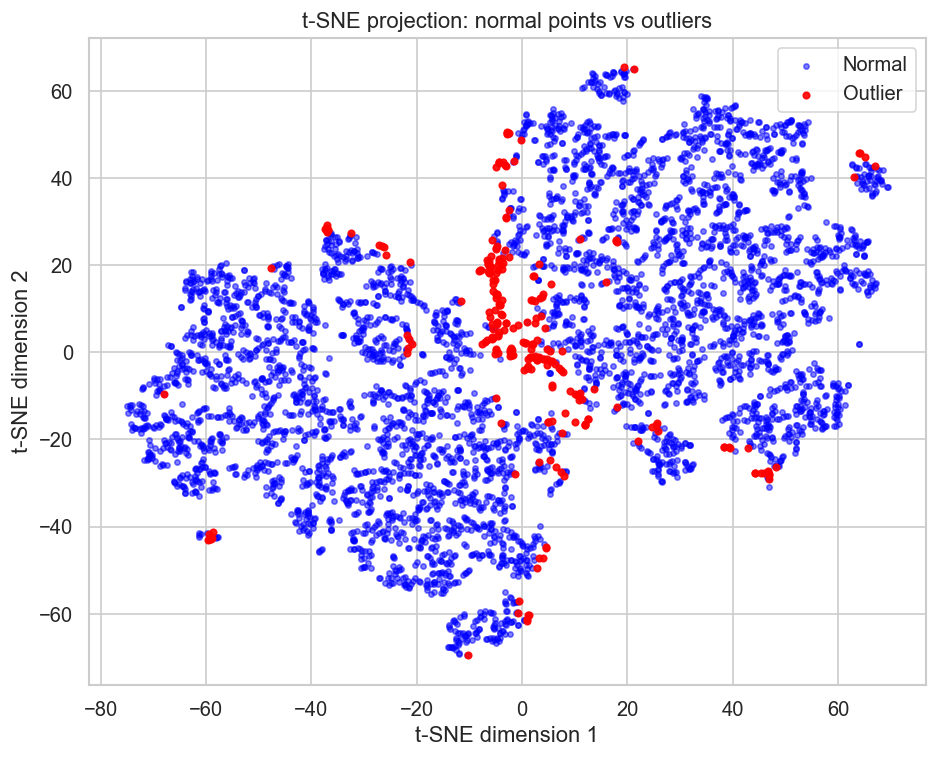

In [32]:
plot_outliers_tsne(outlier_result)

In [33]:
outliers_df = outlier_result.X_inliers[outlier_result.full_outlier_labels == -1].copy()

print("\nLIST OF ALL OUTLIERS FOUND")
outliers_df.head(10)


LIST OF ALL OUTLIERS FOUND


,Age,Gender,FamilyMembers,FinancialEducation,RiskPropensity,Income,Wealth
3,69,1,4,0.767685,0.654597,166.189034,404.997689
17,80,1,1,0.119173,0.098889,6.802567,4.054744
23,81,0,2,0.595024,0.340589,156.063265,462.458278
117,25,0,1,0.571516,0.745596,3.602805,41.655649
122,87,0,4,0.157120,0.060139,13.266355,350.469602
154,78,0,2,0.130559,0.628745,36.812458,655.002664
164,82,1,3,0.222326,0.154917,144.715628,567.784795
231,32,0,4,0.134606,0.163278,196.829694,64.088322
241,76,1,4,0.245409,0.336510,162.155229,338.146963
256,78,1,1,0.156416,0.102797,170.600508,242.172707


In [34]:
def plot_outliers_2d(
    outlier_result: OutlierDetectionResult, feature_1: str = None, feature_2: str = None
) -> None:
    """
    Affiche les points normaux en bleu et les outliers en rouge
    selon deux features choisies.
    """

    X_plot = outlier_result.X_inliers.copy()
    labels = outlier_result.full_outlier_labels.copy()

    # Vérification d'alignement
    if not X_plot.index.equals(labels.index):
        common_index = X_plot.index.intersection(labels.index)
        X_plot = X_plot.loc[common_index].copy()
        labels = labels.loc[common_index].copy()

    # Si les features ne sont pas fournies, on choisit automatiquement
    numeric_cols = X_plot.select_dtypes(include="number").columns.tolist()

    if len(numeric_cols) < 2:
        raise ValueError(
            "Il faut au moins deux colonnes numériques pour faire un affichage 2D."
        )

    if feature_1 is None or feature_2 is None:
        feature_1, feature_2 = numeric_cols[0], numeric_cols[1]

    if feature_1 not in X_plot.columns or feature_2 not in X_plot.columns:
        raise ValueError("Les features choisies n'existent pas dans X_inliers.")

    plot_df = X_plot[[feature_1, feature_2]].copy()
    plot_df["OutlierLabel"] = labels

    normal_df = plot_df[plot_df["OutlierLabel"] == 1]
    outlier_df = plot_df[plot_df["OutlierLabel"] == -1]

    plt.figure(figsize=(8, 6))

    plt.scatter(
        normal_df[feature_1],
        normal_df[feature_2],
        color="blue",
        alpha=0.6,
        s=25,
        label="Normal",
    )

    plt.scatter(
        outlier_df[feature_1],
        outlier_df[feature_2],
        color="red",
        alpha=0.8,
        s=30,
        label="Outlier",
    )

    plt.xlabel(feature_1)
    plt.ylabel(feature_2)
    plt.title(f"Normal vs Outliers: {feature_1} vs {feature_2}")
    plt.legend()
    plt.grid(True)
    plt.show()

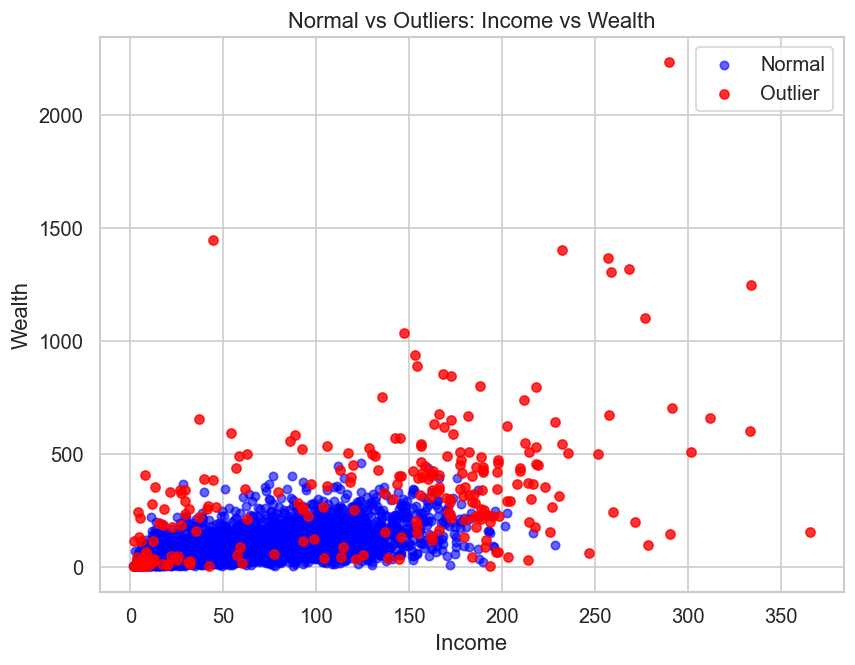

In [35]:
plot_outliers_2d(outlier_result, "Income", "Wealth")

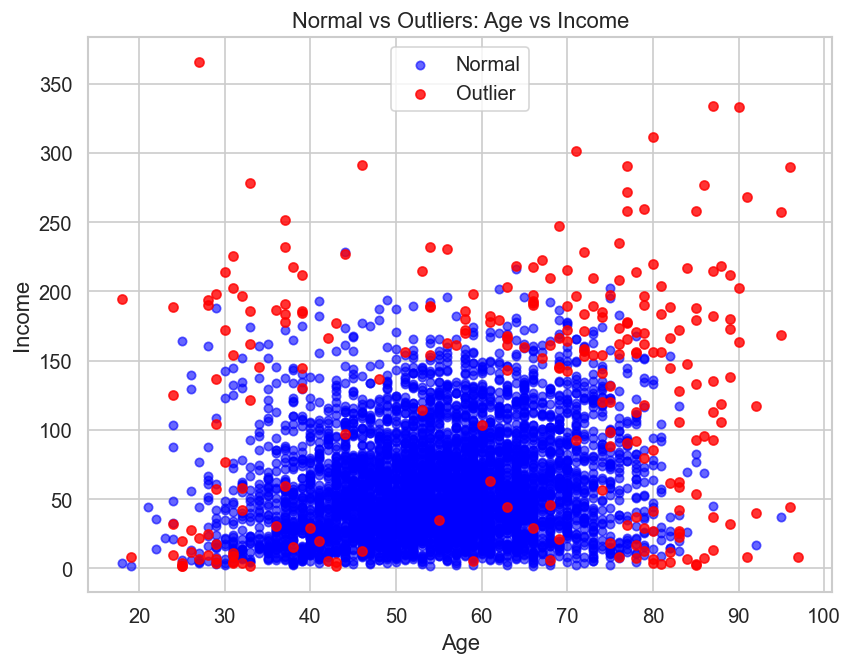

In [36]:
plot_outliers_2d(outlier_result, "Age", "Income")

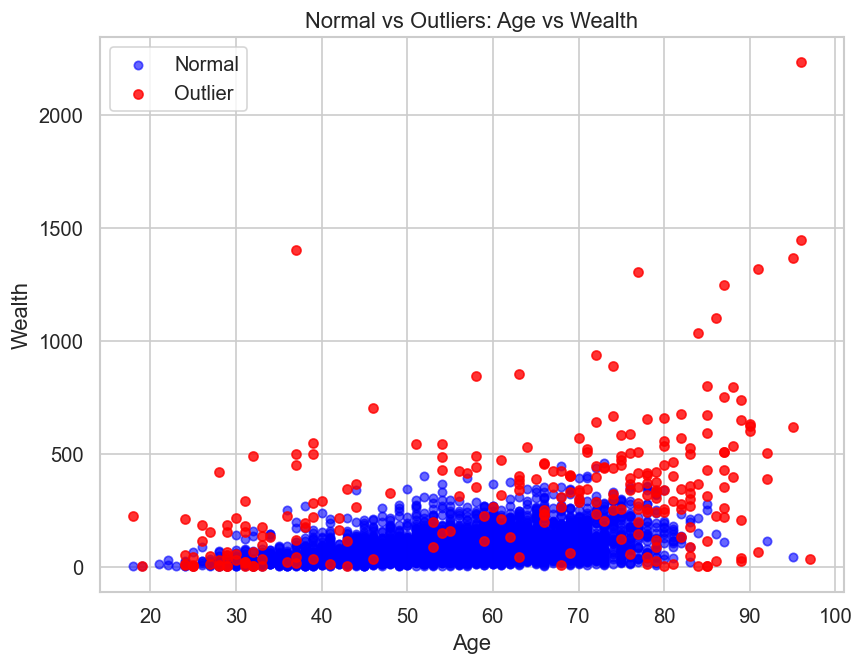

In [37]:
plot_outliers_2d(outlier_result, "Age", "Wealth")

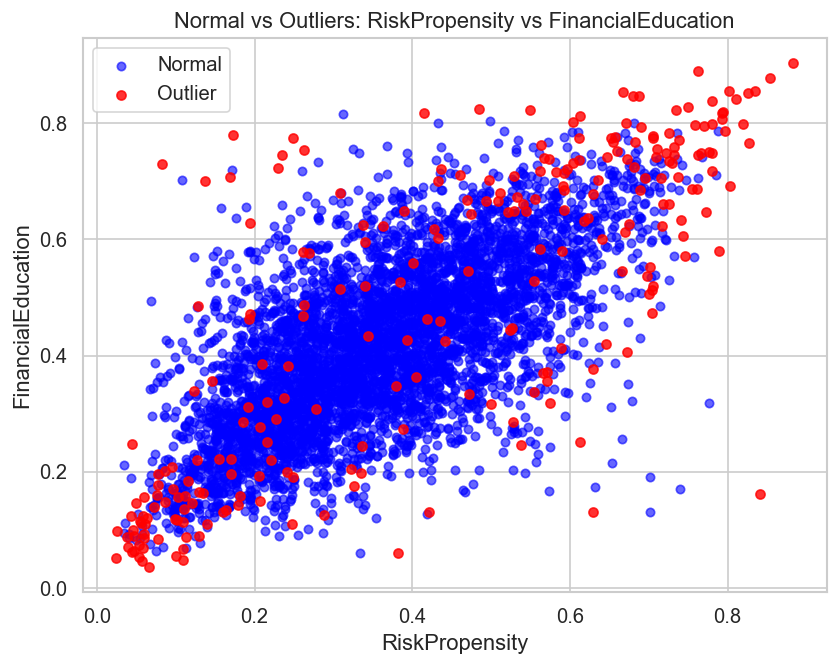

In [38]:
plot_outliers_2d(outlier_result, "RiskPropensity", "FinancialEducation")

But, in reality, financial variables such as Income and Wealth tend to have a greater influence in the analysis because they exhibit much larger scales and higher variability than other features. Their distributions are typically highly skewed, with a small number of individuals holding very large values, which creates extreme observations. As a result, these variables dominate distance-based computations and statistical measures, making them more impactful in tasks such as outlier detection or class prediction. Consequently, we will pay particular attention to these variables and conduct a detailed analysis, variable by variable.


In [ ]:
desc = outlier_result.X_inliers.describe().T
desc["skewness"] = outlier_result.X_inliers.skew()
desc["kurtosis"] = outlier_result.X_inliers.kurtosis()
desc["IQR"] = desc["75%"] - desc["25%"]
desc["CV"] = desc["std"] / desc["mean"]  # Coefficient of variation
print(desc.round(4).to_string())

Now, we can see that the demographic features are relatively well distributed: Age is approximately symmetric around 55 years, and Gender is balanced, which is favorable for modeling. Behavioral variables such as RiskPropensity and FinancialEducation show moderate variability and are likely to contribute meaningfully to prediction. In contrast, financial variables exhibit as we predictied,strong asymmetry: Income is right-skewed, while Wealth is extremely skewed with very high kurtosis, indicating the presence of significant outliers and heavy tails.

So the high dispersion of Income and Wealth indicates that these variables are likely to be key drivers in distinguishing investment profiles.


Although Isolation Forest is more robust than distance-based methods, it remains sensitive to the distribution and scale of the features, especially for financial variables that exhibit large ranges, strong skewness, and extreme values. These characteristics can lead the algorithm to disproportionately identify high-income or high-wealth individuals as outliers. For this reason, it is important to complement Isolation Forest with exploratory tools such as histograms, box plots, and Q-Q plots. These visualizations allow us to analyze each feature individually, understand their distributions, detect skewness and outliers, and make informed decisions about appropriate transformations before applying anomaly detection methods.


## 12. Data Transformation & Feature Engineering


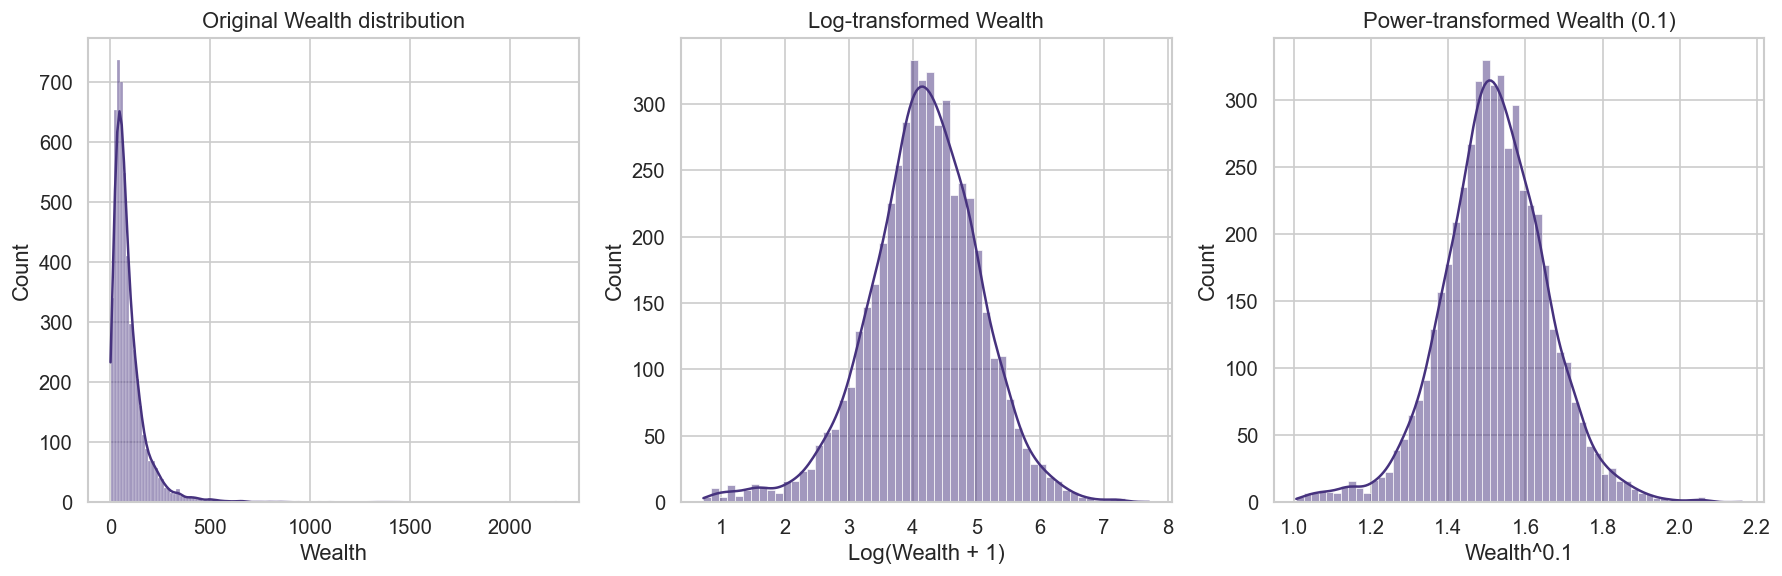

In [39]:
# Wealth transformation analysis
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 5))

# Original distribution
sns.histplot(outlier_result.X_inliers.Wealth, kde=True, ax=ax1)
ax1.set_title("Original Wealth distribution")
ax1.set_xlabel("Wealth")

# Log transformation
sns.histplot(np.log1p(outlier_result.X_inliers.Wealth), kde=True, ax=ax2)
ax2.set_title("Log-transformed Wealth")
ax2.set_xlabel("Log(Wealth + 1)")

# Power transformation
sns.histplot(np.power(outlier_result.X_inliers.Wealth, 0.1), kde=True, ax=ax3)
ax3.set_title("Power-transformed Wealth (0.1)")
ax3.set_xlabel("Wealth^0.1")

plt.tight_layout()
plt.show()


We consider that the classes are already balanced but for the normalisation, we have decided to test which normalisation method is more adequate and obtains the nearest skewness from 0 by checking different values for the power.


--- Statistics for Wealth ---
Original Skewness:    5.830
Log(x+1) Skewness:    -0.371
Optimal Power (0.124): 0.002
------------------------------


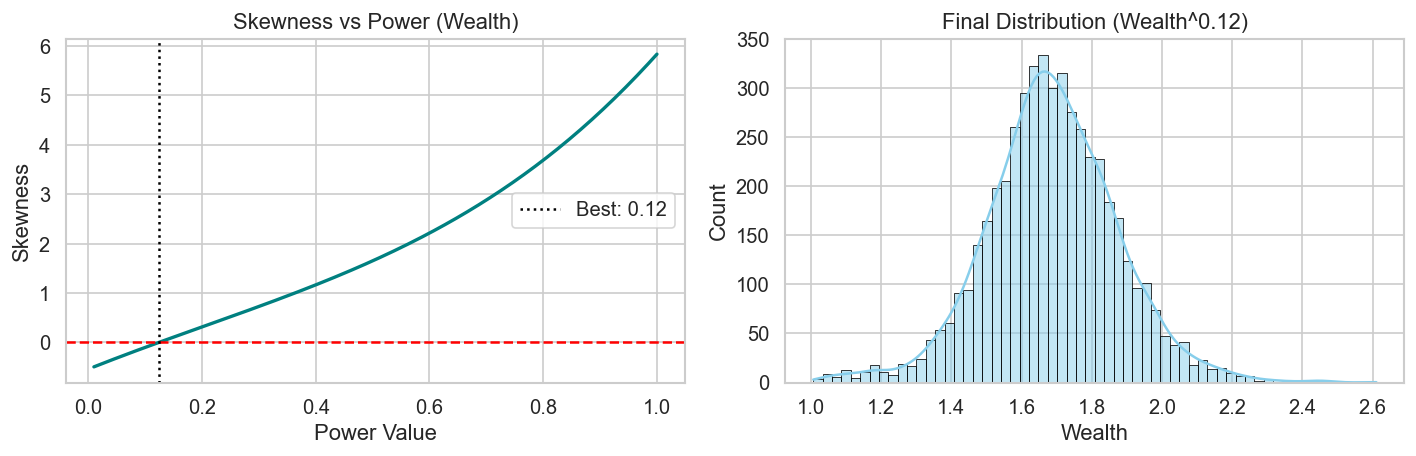

--- Statistics for Income ---
Original Skewness:    1.377
Log(x+1) Skewness:    -0.617
Optimal Power (0.313): 0.004
------------------------------


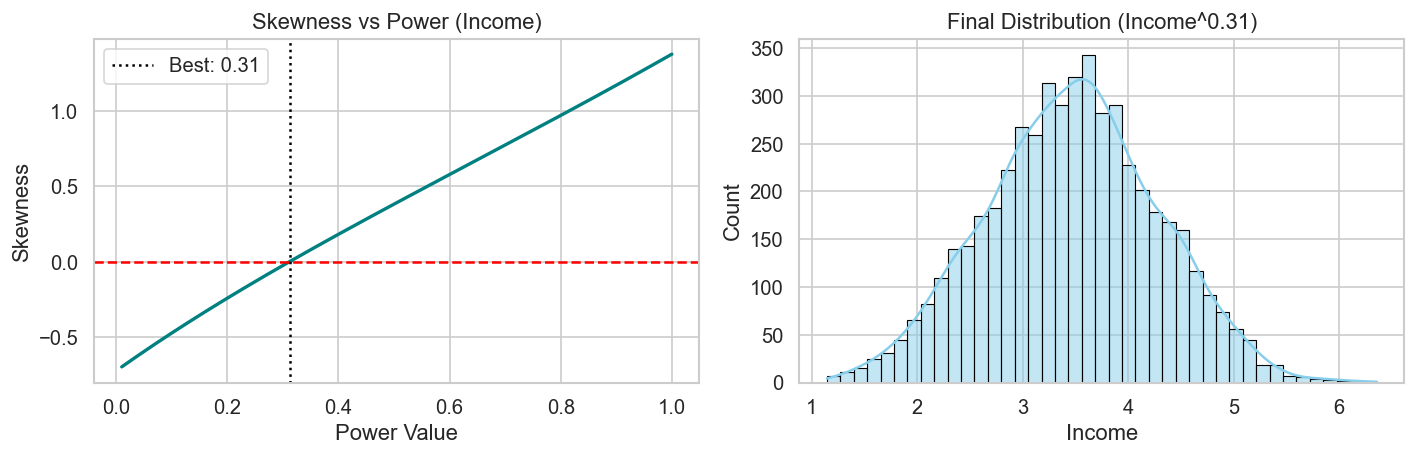

In [40]:
# Define the features to optimize
targets = ["Wealth", "Income"]
powers = np.linspace(0.01, 1.0, 200)
best_powers = {}


for col in targets:
    skewness_results = []
    data_clean = outlier_result.X_inliers[col].dropna()

    # Baseline Comparisons
    orig_skew = skew(data_clean)
    log_skew = skew(np.log1p(data_clean))

    # 1 & 2. Iterate and calculate skewness for Power search
    for p in powers:
        transformed_data = np.power(data_clean, p)
        skewness_results.append(skew(transformed_data))

    # 3. Find optimal power
    best_index = np.argmin(np.abs(skewness_results))
    best_power = powers[best_index]
    best_powers[col] = best_power

    # Print Comparison Statistics
    print(f"--- Statistics for {col} ---")
    print(f"Original Skewness:    {orig_skew:.3f}")
    print(f"Log(x+1) Skewness:    {log_skew:.3f}")
    print(f"Optimal Power ({best_power:.3f}): {skewness_results[best_index]:.3f}")
    print("-" * 30)

    # 4 & 5. Visualization
    plt.figure(figsize=(12, 4))

    # Skewness Curve
    plt.subplot(1, 2, 1)
    plt.plot(powers, skewness_results, color="teal", lw=2)
    plt.axhline(0, color="red", linestyle="--")
    plt.axvline(
        best_power, color="black", linestyle=":", label=f"Best: {best_power:.2f}"
    )
    plt.title(f"Skewness vs Power ({col})")
    plt.xlabel("Power Value")
    plt.ylabel("Skewness")
    plt.legend()

    # Final Distribution
    plt.subplot(1, 2, 2)
    sns.histplot(
        np.power(data_clean, best_power), kde=True, color="skyblue", edgecolor="black"
    )
    plt.title(f"Final Distribution ({col}^{best_power:.2f})")

    plt.tight_layout()
    plt.show()

# Apply the transformations to the new columns
for col, p in best_powers.items():
    outlier_result.X_inliers[f"{col}_pow"] = np.power(outlier_result.X_inliers[col], p)


We tested multiple Power Transformations to normalize the heavily skewed Wealth variable (Original Skew: 5.83) and Income variable (Original Skew: 1.377). We found that a Power Transformation of 0.124 for wealth and 0.313 for income yielded the most symmetric distribution (Skew: 0.00).
